# Imports and dependicies

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import re
import os
import umap 
import seaborn as sns
from collections import Counter, defaultdict
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pywt
from scipy.ndimage import uniform_filter1d


# Load available data

In [ ]:
features_dir = "Project_Features/"
debate_name = "Telejornal_TVI_Dec_18"

visual_file_path = features_dir + debate_name + '_visual.pkl'
speech_file_path = features_dir + debate_name + '_speech.pkl'
audio_file_path = features_dir + debate_name + '_audio.pkl'
ocr_file_path = features_dir + debate_name + '_ocr.pkl'

try:
    with open(visual_file_path, 'rb') as f:
        visual_data = pd.read_pickle(f)
        print("Visual data loaded successfully.")
except FileNotFoundError as e:
    print(f"File not found: {e}")

try:
    with open(ocr_file_path, 'rb') as f:
        ocr_data = pd.read_pickle(f)
        print("OCR data loaded successfully.")
except FileNotFoundError as e:
    print(f"File not found: {e}")

try:
    with open(speech_file_path, 'rb') as f:
        speech_data = pd.read_pickle(f)
        print("Speech data loaded successfully.")
except FileNotFoundError as e:
    print(f"File not found: {e}")

try:
    with open(audio_file_path, 'rb') as f:
        audio_data = pd.read_pickle(f)
        print("Audio data loaded successfully.")
except FileNotFoundError as e:
    print(f"File not found: {e}")



File not found: [Errno 2] No such file or directory: 'Project_Features/Telejornal_TVI_Dec_18_visual.pkl'
OCR data loaded successfully.
Speech data loaded successfully.
File not found: [Errno 2] No such file or directory: 'Project_Features/Telejornal_TVI_Dec_18_audio.pkl'


# Most common words

1769
{'dia': 12, 'após': 3, 'o': 201, 'cenário': 2, 'repete': 1, 'se': 66, 'não': 113, 'era': 14, 'porto': 5, 'de': 234, 'lisboa': 7, 'longas': 1, 'filas': 4, 'para': 73, 'controle': 2, 'fronteiras': 2, 'os': 72, 'passageiros': 2, 'relatam': 1, 'tempos': 1, 'espera': 6, 'que': 292, 'terapáção': 1, 'as': 26, 'três': 7, 'horas': 5, 'dos': 24, 'últimos': 2, 'dias': 7, 'devem': 2, 'sás': 1, 'falhas': 1, 'no': 44, 'sistema': 3, 'mas': 26, 'também': 20, 'a': 244, 'falta': 2, 'policiais': 1, 'governo': 9, 'já': 14, 'reforçou': 1, 'policiamento': 1, 'sindicato': 2, 'profissionais': 1, 'da': 64, 'psp': 3, 'diz': 6, 'é': 127, 'desta': 6, 'forma': 14, 'resolvem': 1, 'este': 10, 'nunciá': 1, 'ainda': 10, 'condições': 2, 'aeroporto': 4, 'retidos': 1, 'são': 20, 'colocados': 1, 'nesta': 2, 'escama': 1, 'campanha': 3, 'escondidas': 1, 'quando': 16, 'há': 23, 'visitas': 1, 'membros': 3, 'do': 62, 'ou': 19, 'até': 15, 'diretor': 1, 'nacional': 4, 'tvi': 4, 'direção': 3, 'polícia': 2, 'comenta': 1, 'dec

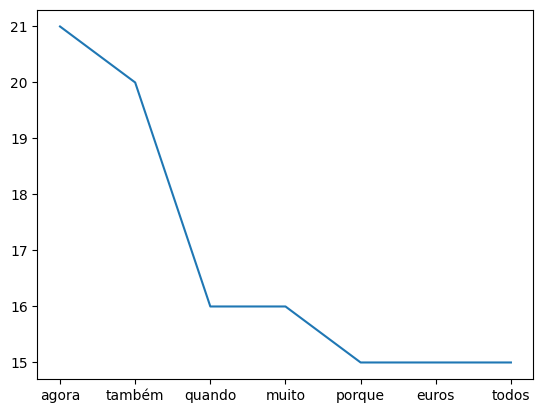

In [3]:
def create_bow(text):
  """Creates a Bag-of-Words representation from text.

  Args:
    text: The input text string.

  Returns:
    A dictionary where keys are words and values are their frequencies.
  """
  words = text.lower().split()  # Convert to lowercase and split into words
  word_counts = Counter(words)  # Count word frequencies
  return dict(word_counts)  # Return as a dictionaryt


ext = speech_data['transcript']

# clean the text of punctuation and numbers
text = ' '.join(speech_data['transcript'])

text = re.sub(r'[^\w\s]', '', text) # remove pontuation
text = re.sub(r'\d+', '', text)  # Remove numbers

bow = create_bow(text)
text = re.sub(r'\d+', '', text)     


print(len(bow.keys()))
print(bow)



# make a new dict with only the n most common words bigger than 4 characters
n = 7
max_len = 4
n_bow = {k: v for k, v in bow.items() if len(k) > max_len}
n_bow = dict(sorted(n_bow.items(), key=lambda item: item[1], reverse=True)[:n])


plt.plot(list(n_bow.keys()), list(n_bow.values()))
plt.show()

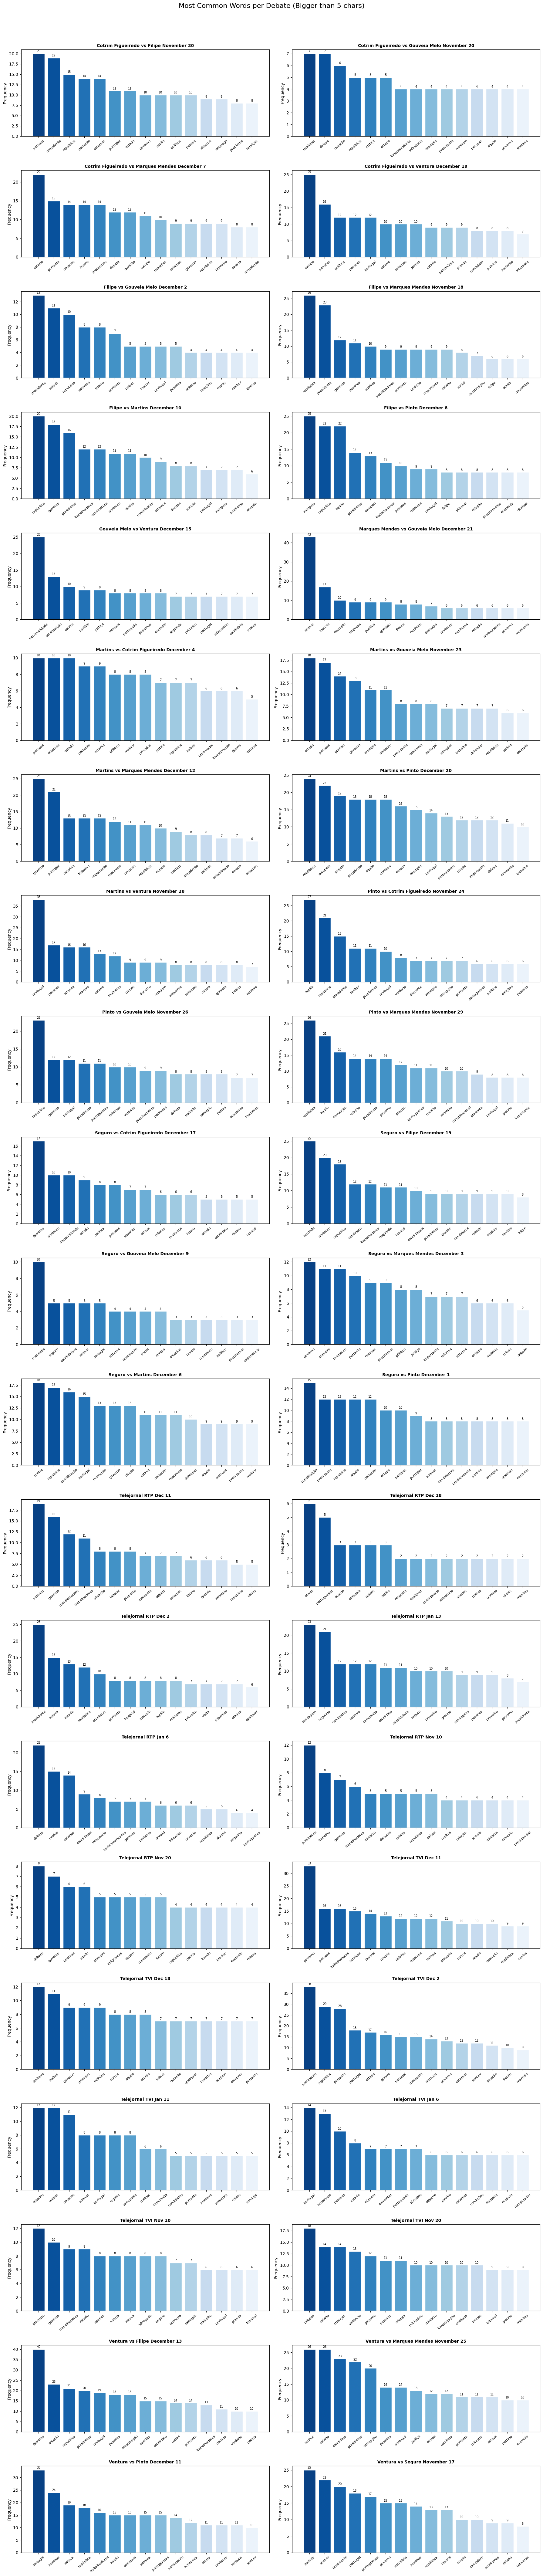

In [34]:
stopwords_pt = {'também', 'porque', 'quando', 'então', 'ainda', 'depois',
                'sempre', 'muito', 'isso', 'aqui', 'sobre', 'mesmo',
                'todos', 'nosso', 'nossa', 'temos', 'podem', 'estar'}



features_dir  = "Project_Features/"
speech_files  = sorted([f for f in os.listdir(features_dir) if f.endswith('_speech.pkl')])

top_n = 15
n_cols = 2
n_rows = -(-len(speech_files) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, file_name in enumerate(speech_files):
    debate = file_name.replace('_speech.pkl', '')
    try:
        df = pd.read_pickle(os.path.join(features_dir, file_name))

        text_blob = ' '.join(df['transcript'].dropna().astype(str).tolist()).lower()
        text_blob = re.sub(r'[^\w\s]', '', text_blob)
        text_blob = re.sub(r'\d+', '', text_blob)

        word_counts = Counter(
            w for w in text_blob.split()
            if len(w) > 5 and w not in stopwords_pt
        )

        top_words = pd.Series(dict(word_counts.most_common(top_n)))

        bars = axes[i].bar(top_words.index, top_words.values,
                           color=sns.color_palette('Blues_r', top_n),
                           edgecolor='white')
        for bar, val in zip(bars, top_words.values):
            axes[i].text(bar.get_x() + bar.get_width() / 2,
                         bar.get_height() + top_words.max() * 0.01,
                         str(val), ha='center', va='bottom', fontsize=7)

        axes[i].set_title(debate.replace('_', ' '), fontsize=10, fontweight='bold')
        axes[i].set_ylabel('Frequency')
        axes[i].tick_params(axis='x', rotation=40, labelsize=8)

    except Exception as e:
        axes[i].set_title(f'{debate} — ERROR', fontsize=9, color='red')
        print(f"Error reading {file_name}: {e}")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Most Common Words per Debate (Bigger than 5 chars)', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

# See available fields in data

In [4]:

print(speech_data.columns.tolist())
print(audio_data.columns.tolist())
print(ocr_data.columns.tolist())

['timestamp', 'duration', 'transcript', 'text_embedding']


NameError: name 'audio_data' is not defined

# Loop snippet to perform in all pkl files

In [ ]:

features_dir = "Project_Features/" 

all_files = [f for f in os.listdir(features_dir) if f.endswith('.pkl')]

for file_name in all_files:
    file_path = os.path.join(features_dir, file_name)
    
    try:
       
    except Exception as e:
        print(f"Error raeding files {file_name}: {e}")


# Dimensionality reduction
  for audio data for debates (PCA VS T-SNE VS UMAP) 

Matrix ready! Shape: (82, 512) (Audio Segments, 512 Features)
Calculating PCA...
Calculating t-SNE...
Calculating UMAP...


/home/pedroalopes3/.local/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


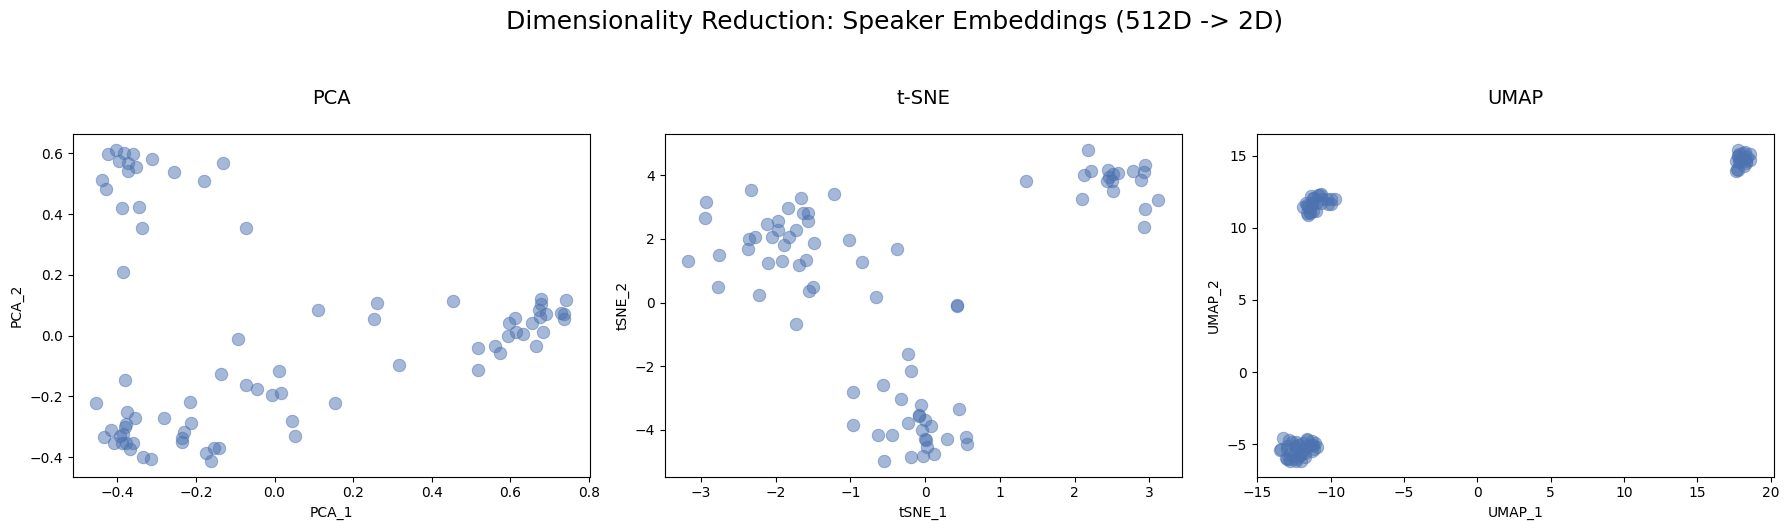

In [ ]:

df_audio = pd.read_pickle('Project_Features/Seguro_vs_Filipe_December_19_audio.pkl')
#df_audio.describe('Project_Features/Seguro_vs_Filipe_December_19_audio.pkl')

df_clean = df_audio.dropna(subset=['speak_embeddings']).copy()
X_embeddings = np.vstack(df_clean['speak_embeddings'].values)

print(f"Matrix ready! Shape: {X_embeddings.shape} (Audio Segments, 512 Features)")

# PCA 

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_embeddings)
df_clean['PCA_1'] = pca_result[:, 0]
df_clean['PCA_2'] = pca_result[:, 1]

# t-SNE 
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_result = tsne.fit_transform(X_embeddings)
df_clean['tSNE_1'] = tsne_result[:, 0]
df_clean['tSNE_2'] = tsne_result[:, 1]

# UMAP 
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
umap_result = umap_model.fit_transform(X_embeddings)
df_clean['UMAP_1'] = umap_result[:, 0]
df_clean['UMAP_2'] = umap_result[:, 1]


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
dot_color = '#4C72B0' 

# PCA Plot
sns.scatterplot(
    ax=axes[0], data=df_clean, x='PCA_1', y='PCA_2', 
    color=dot_color, s=80, alpha=0.5, edgecolor=None
)
axes[0].set_title('PCA\n', fontsize=14)

# t-SNE Plot
sns.scatterplot(
    ax=axes[1], data=df_clean, x='tSNE_1', y='tSNE_2', 
    color=dot_color, s=80, alpha=0.5, edgecolor=None
)
axes[1].set_title('t-SNE\n', fontsize=14)

# UMAP Plot
sns.scatterplot(
    ax=axes[2], data=df_clean, x='UMAP_1', y='UMAP_2', 
    color=dot_color, s=80, alpha=0.5, edgecolor=None
)
axes[2].set_title('UMAP\n', fontsize=14)

plt.suptitle("Dimensionality Reduction: Speaker Embeddings (512D -> 2D)", fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

Matrix ready! Shape: (82, 30) (Audio Segments, 30 Features)
Calculating PCA...
Calculating t-SNE...
Calculating UMAP...


/home/pedroalopes3/.local/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


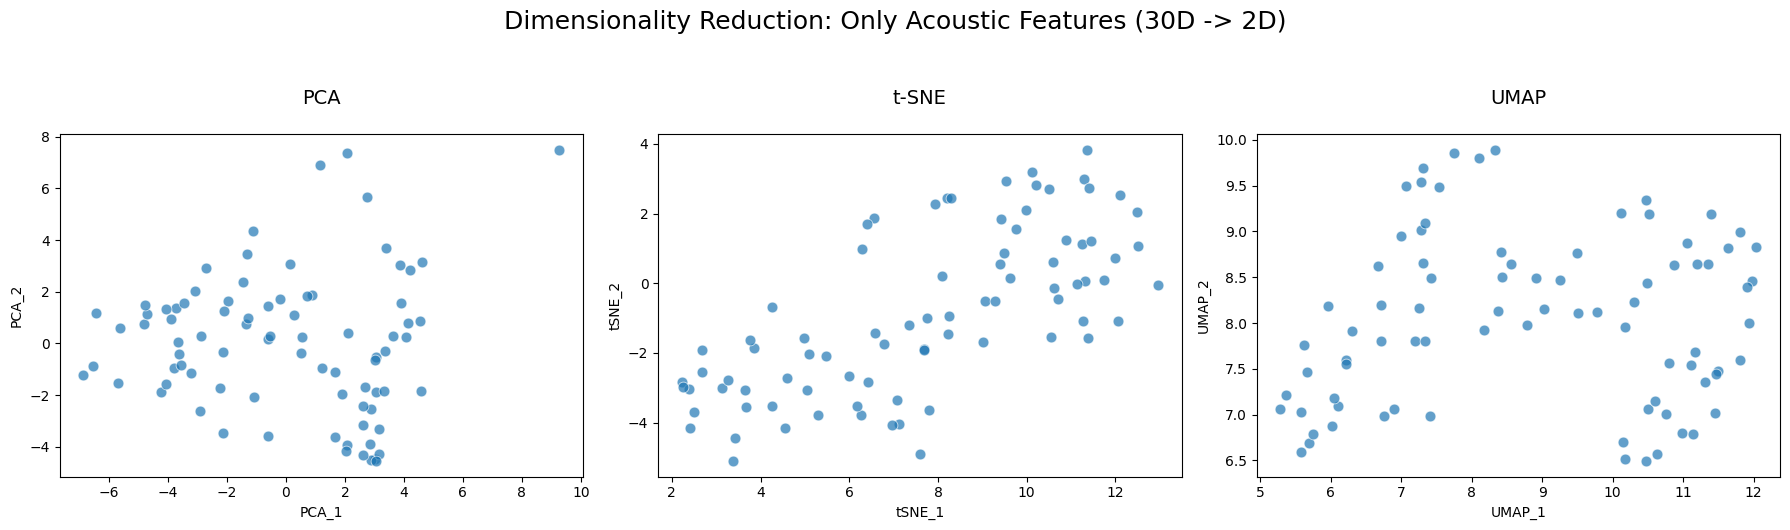

In [ ]:
acoustic_features = [
    'meanF0Hz', 'stdevF0Hz', 'HNR', 'localJitter', 'localabsoluteJitter', 
    'rapJitter', 'ppq5Jitter', 'ddpJitter', 'localShimmer', 'localdbShimmer', 
    'apq3Shimmer', 'apq5Shimmer', 'apq11Shimmer', 'ddaShimmer', 'f1_mean', 
    'f2_mean', 'f3_mean', 'f4_mean', 'f1_median', 'f2_median', 'f3_median', 
    'f4_median', 'npause', 'speechrate', 'articulationrate', 'asd', 'pF', 
    'fdisp', 'avgFormant', 'mff'
]

df_features = df_clean.dropna(subset=acoustic_features).copy()
X_acoustic = df_features[acoustic_features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_acoustic)


pca = PCA(n_components=2)
df_features['PCA_1'] = pca.fit_transform(X_scaled)[:, 0]
df_features['PCA_2'] = pca.fit_transform(X_scaled)[:, 1]

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
df_features['tSNE_1'] = tsne.fit_transform(X_scaled)[:, 0]
df_features['tSNE_2'] = tsne.fit_transform(X_scaled)[:, 1]

umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
df_features['UMAP_1'] = umap_model.fit_transform(X_scaled)[:, 0]
df_features['UMAP_2'] = umap_model.fit_transform(X_scaled)[:, 1]


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cores = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Blue, Orange, Green

# PCA
sns.scatterplot(
    ax=axes[0], data=df_features, x='PCA_1', y='PCA_2', 
    s=60, alpha=0.7, legend=False
)
axes[0].set_title('PCA\n', fontsize=14)

# t-SNE
sns.scatterplot(
    ax=axes[1], data=df_features, x='tSNE_1', y='tSNE_2', 
    s=60, alpha=0.7, legend=False
)
axes[1].set_title('t-SNE\n', fontsize=14)

# UMAP
sns.scatterplot(
    ax=axes[2], data=df_features, x='UMAP_1', y='UMAP_2', 
    s=60, alpha=0.7
)
axes[2].set_title('UMAP\n', fontsize=14)


plt.suptitle("Dimensionality Reduction: Only Acoustic Features (30D -> 2D)", fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

# Finding Themes intervals

Themes: Catch words

  * Estabilidade Politica: estabilidade, magistratura de influência, dissolução, parlamento, moderação, governabilidade, diálogo, crise política, compromisso
  * SNS/Saúde: sns, médicos de família, urgências, listas de espera, setor privado, saúde, profissionais de saúde, hospitais, hospital
  * Habitação: habitação, rendas, especulação imobiliária, oferta, construção, crédito habitação, crise habitacional, licenciamento, impostos,poder de compra
  * Imigração: imigração, nacionalidade, fronteiras, integração, demografia, segurança, regularização, xenofobia, multiculturalismo
  * Macroeconomia: macroeconomia, economia, inflação, custo de vida, salários, impostos, crescimento económico, concertação social, poder de compra, pacote laboral 
  * Defesa: defesa, forças armadas, investimento, nato, guerra, recrutamento militar, armamento, geoestratégia, soberania, segurança nacional, marinha, exercito, força aerea
  * Juventude: jovens, juventude, fuga de cérebros, emigração jovem, oportunidades, salários de entrada, precariedade, futuro seguro, retenção de talento, elevador social
  * Justiça/Corrupção: justiça, corrupção, impunidade, transparência, tribunais, ministério público, tribunal constitucional, reforma da justiça, morosidade, escrutínio
  * Crise Ambiental: ambiente, alterações climáticas, tempestade, incêndios, proteção civil, estado de calamidade, sustentabilidade, transição climática, apoios estatais, ecologia
  * Eleições: eleições,voto, candidatos, campanha, partidos políticos,debate eleitoral,programas eleitorais, promessas de campanha, votação, eleitores



For one debate

In [ ]:

temas_dict = {
    "Estabilidade Politica": ["estabilidade", "magistratura de influência", "dissolução", "parlamento", "moderação", "governabilidade", "diálogo", "crise política", "compromisso"],
    "SNS/Saúde": ["sns", "médicos de família", "urgências", "listas de espera", "setor privado", "saúde", "profissionais de saúde", "hospitais", "hospital"],
    "Habitação": ["habitação", "rendas", "especulação imobiliária", "oferta", "construção", "crédito habitação", "crise habitacional", "licenciamento", "impostos", "poder de compra"],
    "Imigração": ["imigração", "nacionalidade", "fronteiras", "integração", "demografia", "segurança", "regularização", "xenofobia", "multiculturalismo"],
    "Macroeconomia": ["macroeconomia", "economia", "inflação", "custo de vida", "salários", "impostos", "crescimento económico", "concertação social", "poder de compra", "pacote laboral"],
    "Defesa": ["defesa", "forças armadas", "investimento", "nato", "guerra", "recrutamento militar", "armamento", "geoestratégia", "soberania", "segurança nacional", "marinha", "exercito", "força aerea"],
    "Juventude": ["jovens", "juventude", "fuga de cérebros", "emigração jovem", "oportunidades", "salários de entrada", "precariedade", "futuro seguro", "retenção de talento", "elevador social"],
    "Justiça/Corrupção": ["justiça", "corrupção", "impunidade", "transparência", "tribunais", "ministério público", "tribunal constitucional", "reforma da justiça", "morosidade", "escrutínio"],
    "Crise Ambiental": ["ambiente", "alterações climáticas", "tempestade", "incêndios", "proteção civil", "estado de calamidade", "sustentabilidade", "transição climática", "apoios estatais", "ecologia"],
    "Eleições": ["eleições", "voto", "candidatos", "campanha", "partidos políticos", "debate eleitoral", "programas eleitorais", "promessas de campanha", "votação", "eleitores"]
}

df_speech = pd.read_pickle('Project_Features/Seguro_vs_Filipe_December_19_speech.pkl')

# detetar o tema dominante numa frase
def detetar_tema(texto):
    if not isinstance(texto, str):
        return "Sem Tema Claro"
    
    texto_lower = texto.lower()
    contagens = {}
    
    for tema, palavras in temas_dict.items():
        count = 0
        for palavra in palavras:
            count += len(re.findall(r'\b' + re.escape(palavra) + r'\b', texto_lower))
        if count > 0:
            contagens[tema] = count
            
   
    if contagens:
        tema_dominante = max(contagens, key=contagens.get)
        return tema_dominante
    else:
        return "Sem Tema Claro"


df_speech['Tema'] = df_speech['transcript'].apply(detetar_tema)


intervalos_temas = []
tema_atual = None
inicio_atual = 0

for index, row in df_speech.sort_values('timestamp').iterrows():
    tema_linha = row['Tema']
  
    if tema_linha != tema_atual:
     
        if tema_atual is not None and tema_atual != "Sem Tema Claro":
            fim_anterior = df_speech.loc[index_anterior, 'timestamp'] + df_speech.loc[index_anterior, 'duration']
            intervalos_temas.append({
                'Tema': tema_atual,
                'Start Time (s)': round(inicio_atual, 2),
                'End Time (s)': round(fim_anterior, 2),
                'Duração (s)': round(fim_anterior - inicio_atual, 2)
            })
        

        tema_atual = tema_linha
        inicio_atual = row['timestamp']
        
    index_anterior = index

if tema_atual is not None and tema_atual != "Sem Tema Claro":
    fim_anterior = df_speech.loc[index_anterior, 'timestamp'] + df_speech.loc[index_anterior, 'duration']
    intervalos_temas.append({
        'Tema': tema_atual,
        'Start Time (s)': round(inicio_atual, 2),
        'End Time (s)': round(fim_anterior, 2),
        'Duração (s)': round(fim_anterior - inicio_atual, 2)
    })

df_intervalos = pd.DataFrame(intervalos_temas)

display(df_intervalos)

📅 Cronologia dos Temas Discutidos no Debate:


,Tema,Start Time (s),End Time (s),Duração (s)
0,Justiça/Corrupção,79.82,131.03,51.22
1,Eleições,190.52,238.64,48.13
2,Eleições,261.27,362.03,100.76
3,Eleições,428.08,452.03,23.95
4,Macroeconomia,470.34,553.87,83.53
5,Estabilidade Politica,632.62,814.18,181.56
6,Juventude,886.63,910.10,23.47
7,Macroeconomia,959.85,1117.49,157.65
8,Imigração,1119.27,1177.70,58.44
9,Estabilidade Politica,1257.25,1315.00,57.75


Using wavelet transcript analysis (for one theme)

NameError: name 'tema_alvo' is not defined

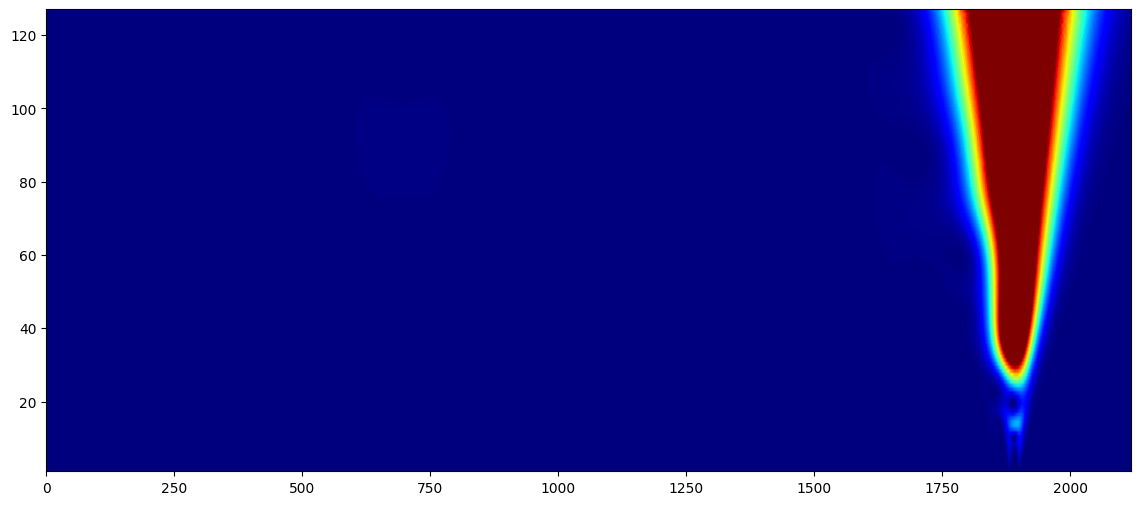

In [ ]:

debate_length_sec = int(df_speech['timestamp'].max() + df_speech['duration'].iloc[-1]) + 1


# array of zeros representing every second of the debate
signal = np.zeros(debate_length_sec)

catchwords_saude = ["sns", "médicos", "urgências", "saúde", "hospitais"]

# count number of catchwords in each sentence and add to the signal
for index, row in df_speech.iterrows():
    start_time = int(row['timestamp'])
    duration = int(max(1, row['duration']))
    text = str(row['transcript']).lower()
    
    # Count how many catchwords are in this sentence
    hits = sum(text.count(word) for word in catchwords_saude)
    
    if hits > 0:
        signal[start_time:start_time+duration] += hits / duration

# wavelet calc
wavelet = 'cmor1.5-1.0' # morlet wavelet
scales = np.arange(1, 128)

# Calculate the coefficients (power) and the corresponding frequencies
coefficients, frequencies = pywt.cwt(signal, scales, wavelet, sampling_period=1)


power = (abs(coefficients)) ** 2

#plot
plt.figure(figsize=(14, 6))
plt.imshow(power, extent=[0, debate_length_sec, scales[-1], scales[0]], 
           cmap='jet', aspect='auto', vmax=power.max()*0.5) 

plt.gca().invert_yaxis() 
plt.title(f'Wavelet Scalogram (Time-Frequency Analysis) for Theme: {tema_alvo}', fontsize=16)
plt.ylabel('Scale (Seconds / Period)', fontsize=12)
plt.xlabel('Time in Debate (Seconds)', fontsize=12)
plt.colorbar(label='Theme Intensity (Power)')

plt.plot(np.linspace(0, debate_length_sec, len(signal)), signal * 10, color='white', alpha=0.5, label='Raw Text Signal')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

for all themes

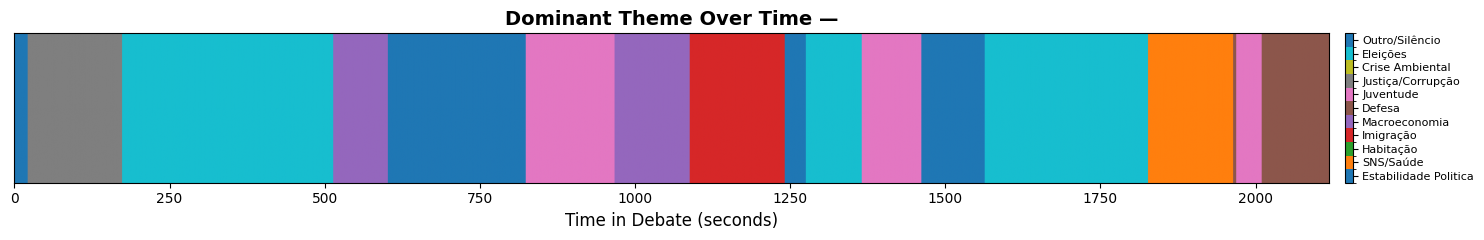

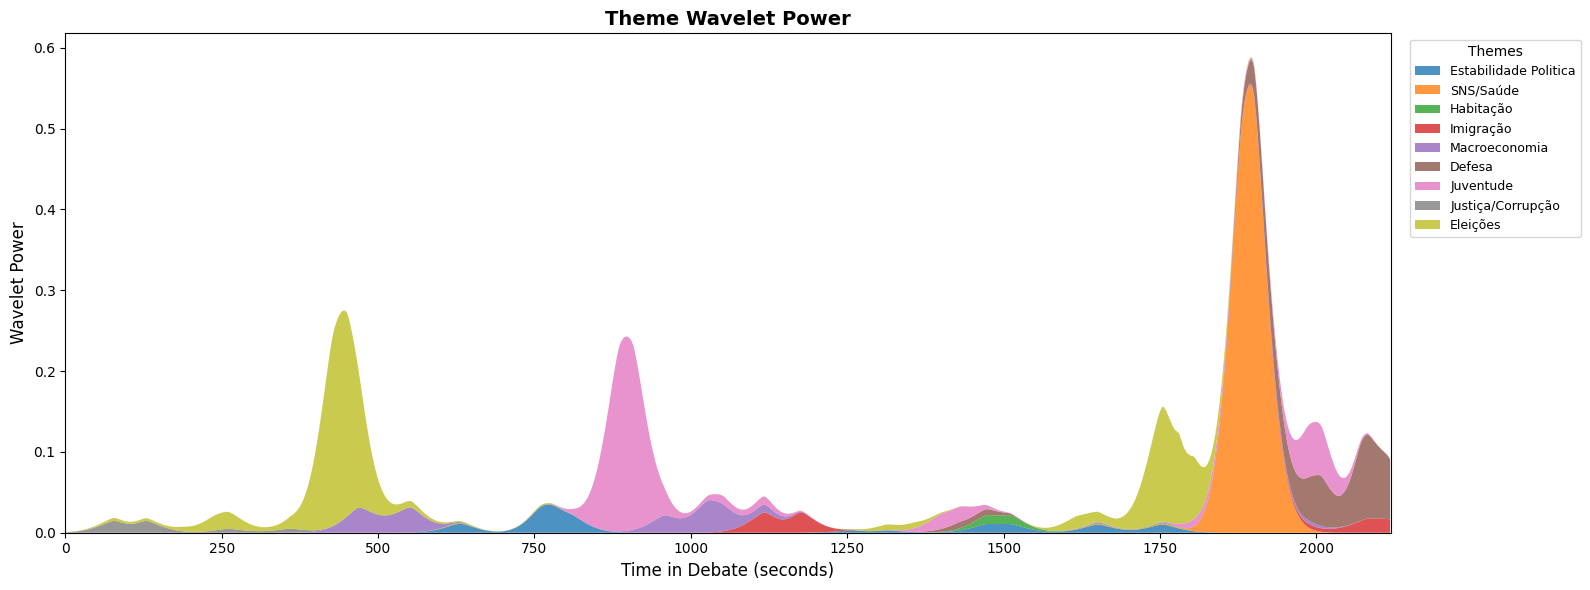

In [ ]:
wavelet = 'cmor1.5-1.0'
scales  = np.arange(0.1, 64)
poder_tematico = {}

for tema, sinal in signals.items():
    if np.sum(sinal) > 0:
        coeffs, _ = pywt.cwt(sinal, scales, wavelet, sampling_period=1)
        power = (np.abs(coeffs)) ** 2
        poder_tematico[tema] = np.sum(power, axis=0)
    else:
        poder_tematico[tema] = np.zeros(debate_length_sec)

df_power = pd.DataFrame(poder_tematico)


limiar_energia            = 0.002
tema_dominante            = df_power.idxmax(axis=1)
max_energia               = df_power.max(axis=1)
tema_dominante[max_energia < limiar_energia] = "Outro/Silêncio"


all_themes  = [t for t in temas_dict.keys()] + ["Outro/Silêncio"]
theme2idx   = {t: i for i, t in enumerate(all_themes)}
color_signal = np.array([theme2idx[t] for t in tema_dominante])

palette = sns.color_palette('tab10', len(all_themes))
cmap    = mpl.colors.ListedColormap(palette)
bounds  = np.arange(len(all_themes) + 1) - 0.5
norm    = mpl.colors.BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(16, 2.5))
img = ax.imshow(color_signal[np.newaxis, :], aspect='auto',
                cmap=cmap, norm=norm,
                extent=[0, debate_length_sec, 0, 1])
ax.set_yticks([])
ax.set_xlabel('Time in Debate (seconds)', fontsize=12)
ax.set_title('Dominant Theme Over Time —', fontsize=14, fontweight='bold')

cbar = plt.colorbar(img, ax=ax, orientation='vertical', pad=0.01)
cbar.set_ticks(range(len(all_themes)))
cbar.set_ticklabels(all_themes, fontsize=8)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(16, 6))
ax.stackplot(range(debate_length_sec),
             [df_power[t].values for t in temas_dict if np.sum(signals[t]) > 0],
             labels=[t for t in temas_dict if np.sum(signals[t]) > 0],
             colors=sns.color_palette('tab10', len(temas_dict)),
             alpha=0.8)
ax.set_title('Theme Wavelet Power', fontsize=14, fontweight='bold')
ax.set_xlabel('Time in Debate (seconds)', fontsize=12)
ax.set_ylabel('Wavelet Power', fontsize=12)
ax.set_xlim(0, debate_length_sec)
ax.legend(title='Themes', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

# News missing data analysis

✓ Loaded: Project_Features/Cotrim_Figueiredo_vs_Ventura_December_19_audio.pkl — (102, 33)
✓ Loaded: Project_Features/Cotrim_Figueiredo_vs_Ventura_December_19_speech.pkl — (37, 4)
✓ Loaded: Project_Features/Cotrim_Figueiredo_vs_Ventura_December_19_visual.pkl — (2165, 3)

=== Audio DATA ===
Shape: (102, 33)


,time stamp,duration,meanF0Hz,stdevF0Hz,HNR,localJitter,localabsoluteJitter,rapJitter,ppq5Jitter,ddpJitter,...,f4_median,npause,speechrate,articulationrate,asd,speak_embeddings,pF,fdisp,avgFormant,mff
count,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000,...,102.000000,102.000000,102.000000,102.000000,102.000000,102,1.020000e+02,102.000000,102.000000,102.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,102,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,"[-0.07669693, 0.002468539, -0.029221741, 0.060...",NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN
mean,1061.431892,21.462647,171.610468,39.209076,10.928712,0.027687,0.000165,0.009520,0.012631,0.028559,...,3509.305852,1.401961,5.164711,5.284158,0.190609,NaN,3.163047e-15,1021.752937,1950.966135,1519.526133
std,647.009197,20.374412,21.619580,8.013520,1.522678,0.002485,0.000029,0.001381,0.001504,0.004144,...,124.970279,1.884065,0.509320,0.446143,0.016432,NaN,7.965334e-01,37.988956,63.904867,60.060051
min,3.777000,5.434000,123.040844,18.596170,7.231566,0.021866,0.000105,0.005986,0.008334,0.017959,...,3299.341485,0.000000,3.703704,4.107788,0.157636,NaN,-1.418999e+00,965.309335,1839.373625,1410.869978
25%,465.354500,8.479500,156.721596,33.141654,9.718555,0.026206,0.000145,0.008464,0.011778,0.025393,...,3416.352628,0.000000,4.809217,4.988526,0.179140,NaN,-5.938291e-01,993.846493,1897.462648,1475.965591
50%,1014.775000,14.344000,174.130674,40.600880,11.028852,0.027678,0.000162,0.009456,0.012415,0.028367,...,3498.326996,1.000000,5.158335,5.298128,0.188747,NaN,-2.830216e-02,1013.562869,1952.777290,1517.892181
75%,1632.729500,26.223500,190.404175,44.962348,12.111896,0.029087,0.000179,0.010252,0.013525,0.030756,...,3567.642545,2.000000,5.525911,5.582239,0.200460,NaN,4.921215e-01,1044.517954,1984.958655,1568.153168



=== Speech DATA ===
Shape: (37, 4)


,timestamp,duration,transcript,text_embedding
count,37.000000,37.000000,37,37
unique,NaN,NaN,37,37
top,NaN,NaN,Boa noite. É um mês das presidenciais hoje de...,"[1.727637, -0.041435923, 0.29471213, 0.1202736..."
freq,NaN,NaN,1,1
mean,1077.278973,40.566541,NaN,NaN
std,655.322142,23.416347,NaN,NaN
min,3.777000,20.048000,NaN,NaN
25%,505.792000,25.599000,NaN,NaN
50%,1060.912000,32.349000,NaN,NaN
75%,1659.316000,41.512000,NaN,NaN



=== Visual DATA ===
Shape: (2165, 3)


,Frame,Poses,Fer
count,2165,2165,2165
unique,2165,2163,2165
top,Frames/Cotrim_Figueiredo_vs_Ventura_December_1...,[],"[{'bbox': [1127, 453, 1172, 516], 'top_emotion..."
freq,1,3,1


/tmp/ipykernel_9171/504769894.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing.values, y=missing.index, ax=ax, palette='Reds_r')
/tmp/ipykernel_9171/504769894.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing.values, y=missing.index, ax=ax, palette='Reds_r')
/tmp/ipykernel_9171/504769894.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing.values, y=missing.index, ax=ax, palette='Reds_r')


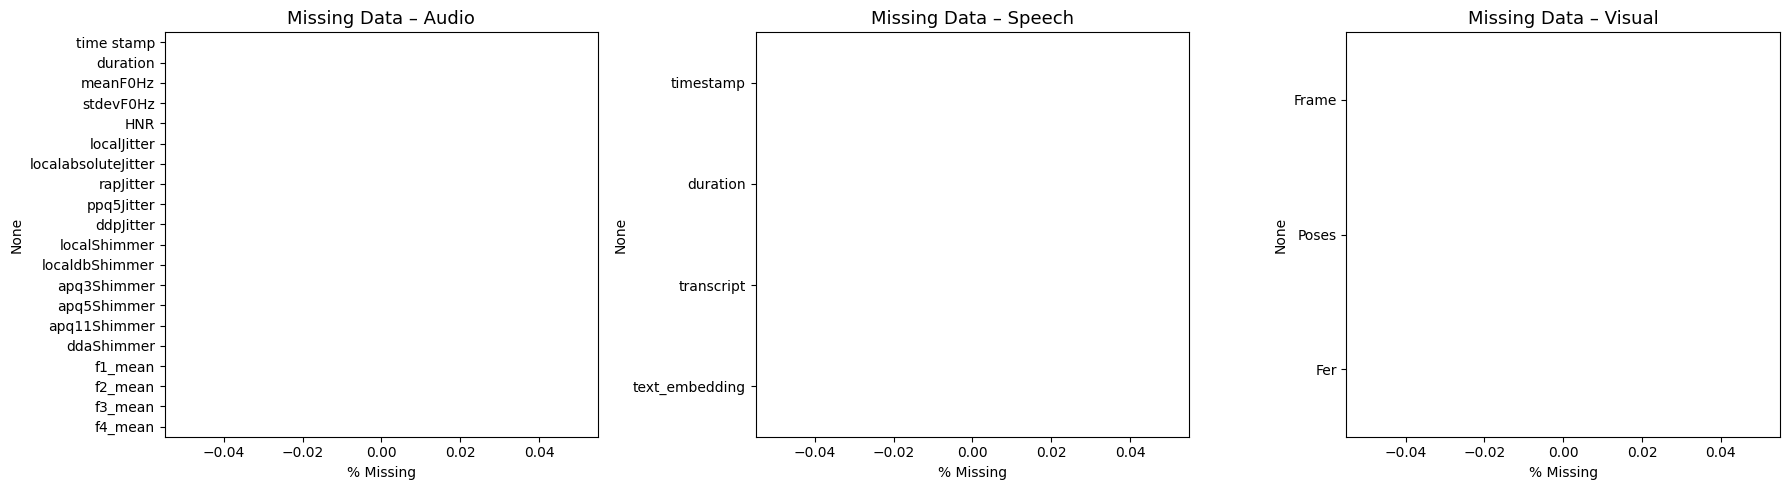

In [ ]:
# Data loading 
features_dir = "Project_Features/"
debate_name = "Cotrim_Figueiredo_vs_Ventura_December_19"

def safe_load(path):
    try:
        df = pd.read_pickle(path)
        print(f"✓ Loaded: {path} — {df.shape}")
        return df
    except FileNotFoundError:
        print(f"✗ Not found: {path}")
        return None

df_audio   = safe_load(features_dir + debate_name + '_audio.pkl')
df_speech  = safe_load(features_dir + debate_name + '_speech.pkl')
df_visual  = safe_load(features_dir + debate_name + '_visual.pkl')


for df, name in [(df_audio, 'Audio'), (df_speech, 'Speech'), (df_visual, 'Visual')]:
    if df is None:
        print(f"\n[{name}] — data not available, skipping.")
        continue
    print(f"\n=== {name} DATA ===")
    print(f"Shape: {df.shape}")
    display(df.describe(include='all'))


available = [(df, name) for df, name in [(df_audio, 'Audio'), (df_speech, 'Speech'), (df_visual, 'Visual')] if df is not None]

if available:
    fig, axes = plt.subplots(1, len(available), figsize=(6 * len(available), 5))
    if len(available) == 1:
        axes = [axes]
    for ax, (df, name) in zip(axes, available):
        missing = df.isna().mean().sort_values(ascending=False).head(20)
        sns.barplot(x=missing.values, y=missing.index, ax=ax, palette='Reds_r')
        ax.set_title(f'Missing Data – {name}', fontsize=13)
        ax.set_xlabel('% Missing')
    plt.tight_layout()
    plt.show()

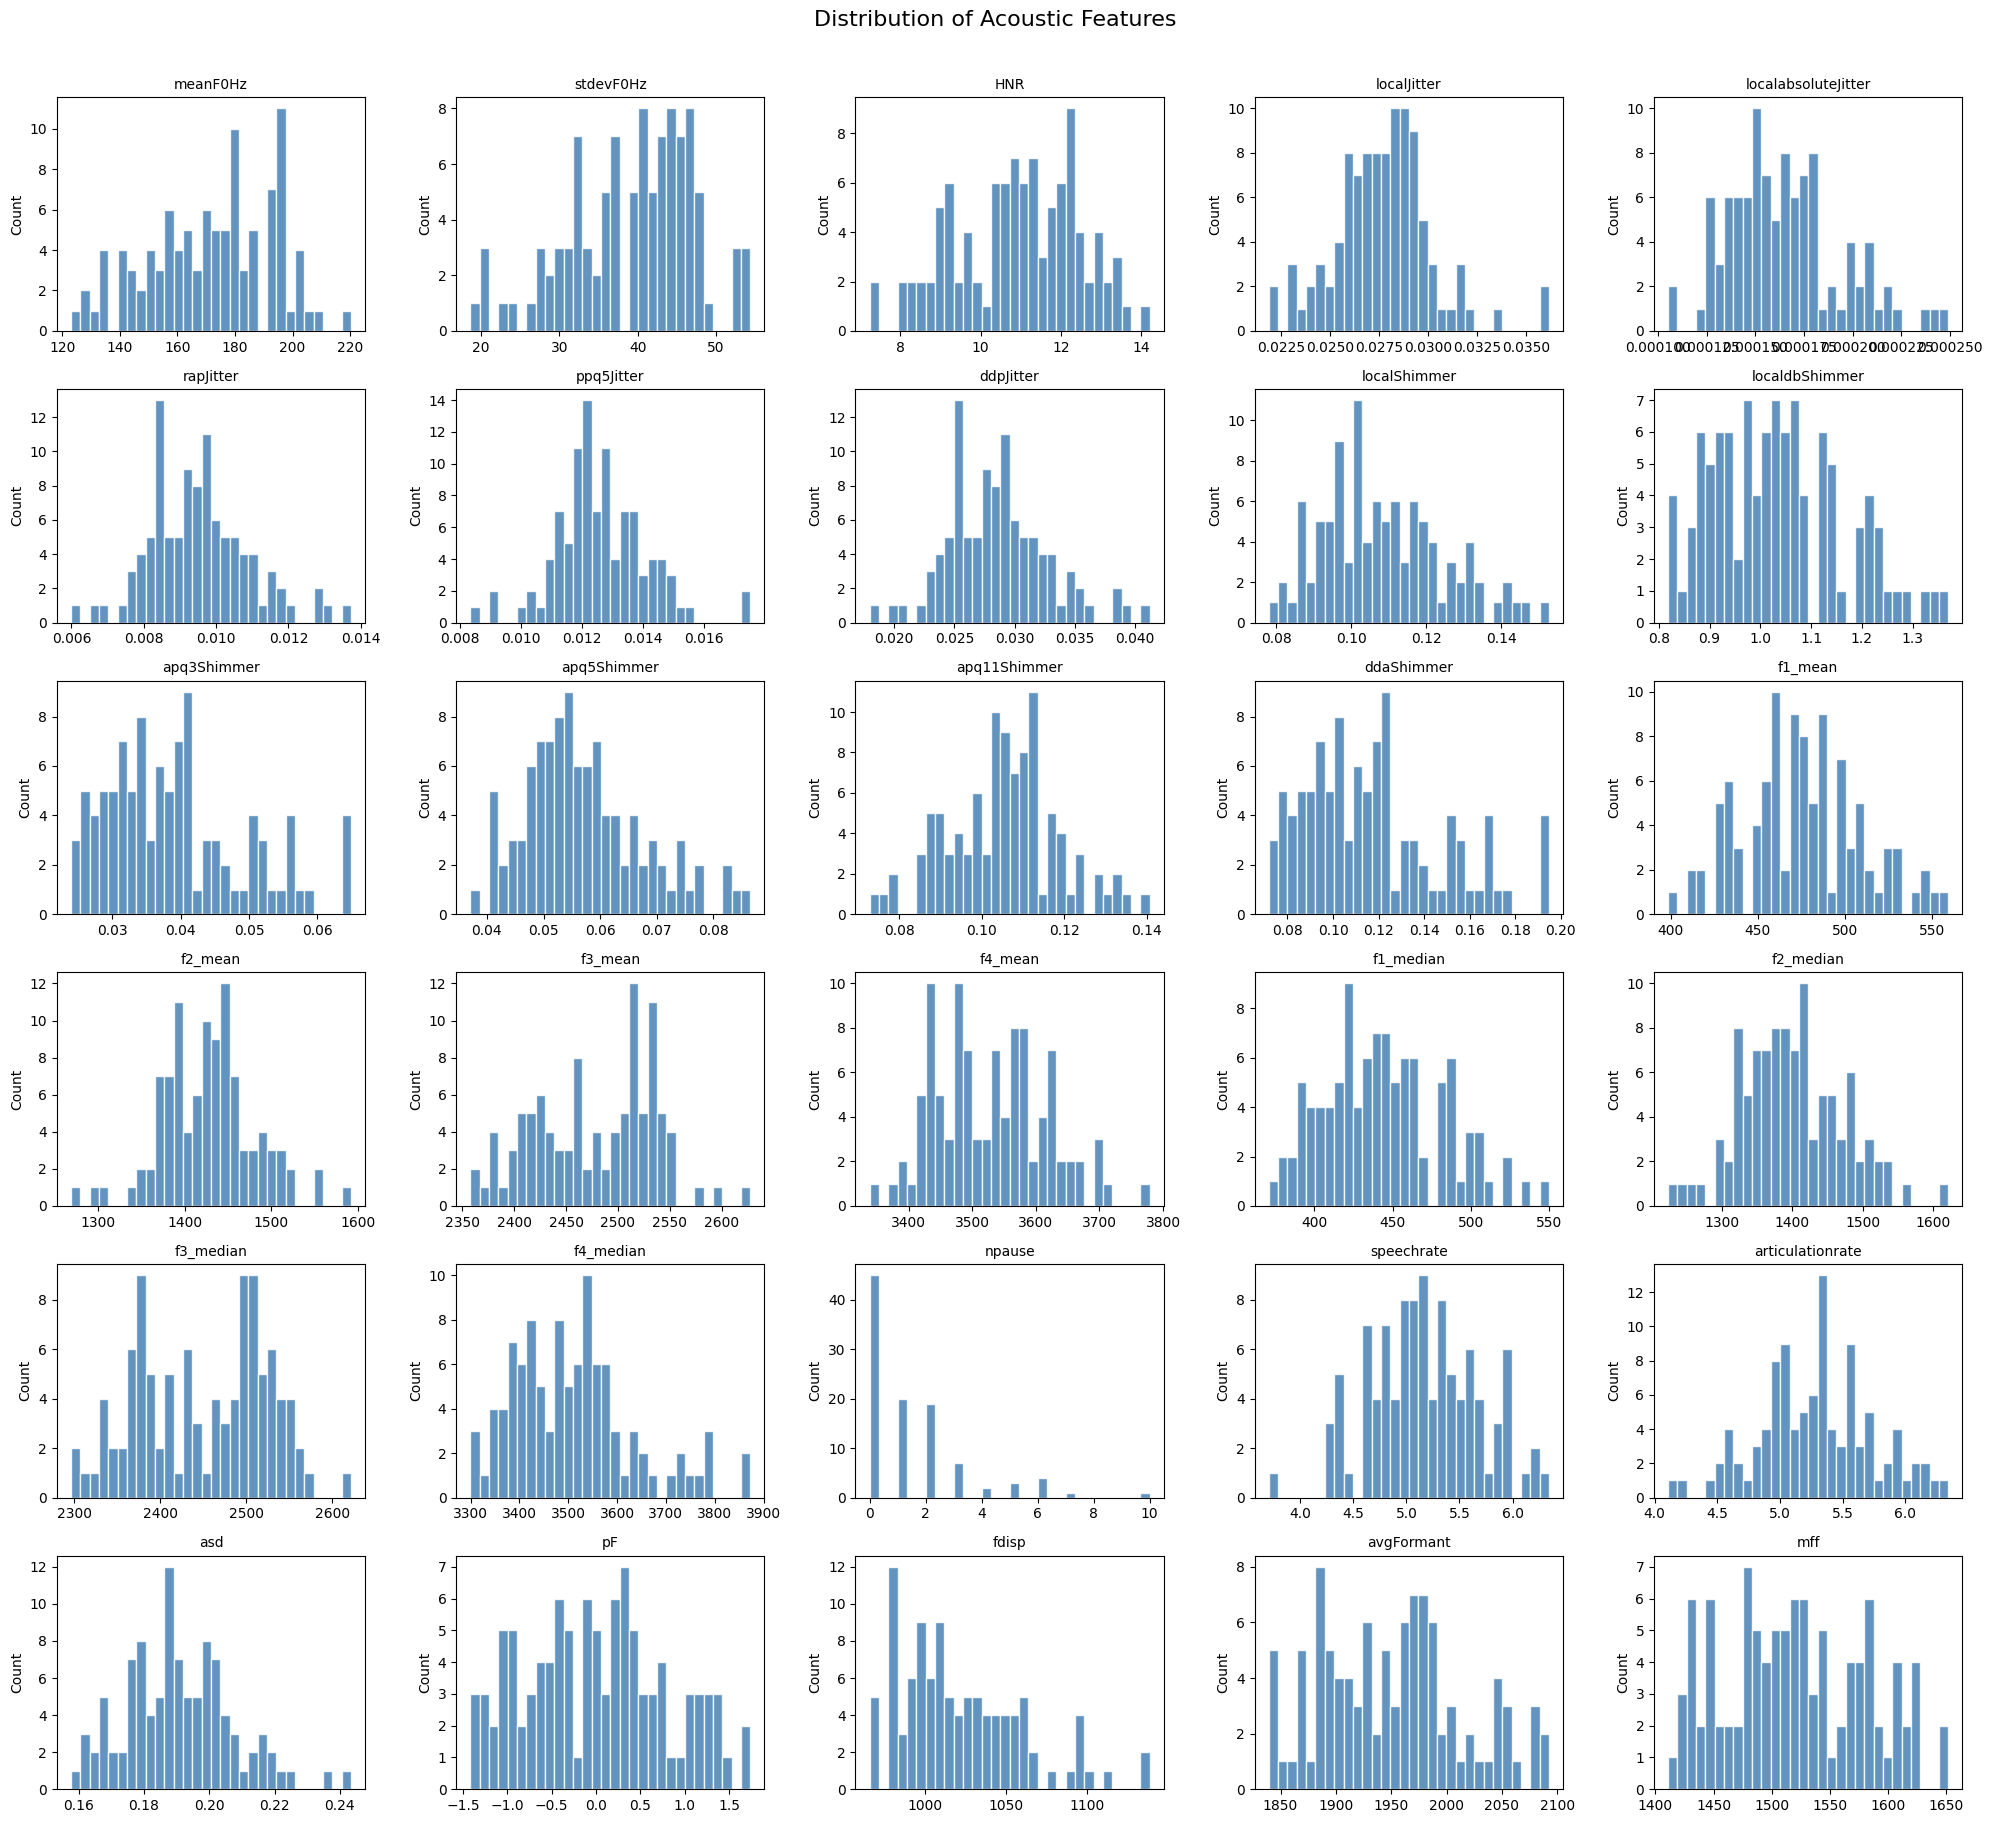

In [ ]:
acoustic_features = [
    'meanF0Hz', 'stdevF0Hz', 'HNR', 'localJitter', 'localabsoluteJitter',
    'rapJitter', 'ppq5Jitter', 'ddpJitter', 'localShimmer', 'localdbShimmer',
    'apq3Shimmer', 'apq5Shimmer', 'apq11Shimmer', 'ddaShimmer',
    'f1_mean', 'f2_mean', 'f3_mean', 'f4_mean',
    'f1_median', 'f2_median', 'f3_median', 'f4_median',
    'npause', 'speechrate', 'articulationrate', 'asd', 'pF', 'fdisp', 'avgFormant', 'mff'
]

if df_audio is None:
    print("Audio data not available — skipping histogram grid.")
else:
    available_feats = [f for f in acoustic_features if f in df_audio.columns]
    df_audio_clean = df_audio[available_feats].dropna()

    n_cols = 5
    n_rows = -(-len(available_feats) // n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3))
    axes = axes.flatten()

    for i, feat in enumerate(available_feats):
        axes[i].hist(df_audio_clean[feat], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
        axes[i].set_title(feat, fontsize=10)
        axes[i].set_ylabel('Count')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Distribution of Acoustic Features', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_448161/1205359068.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=emotion_counts.index, y=emotion_counts.values, ax=axes[0], palette='viridis')


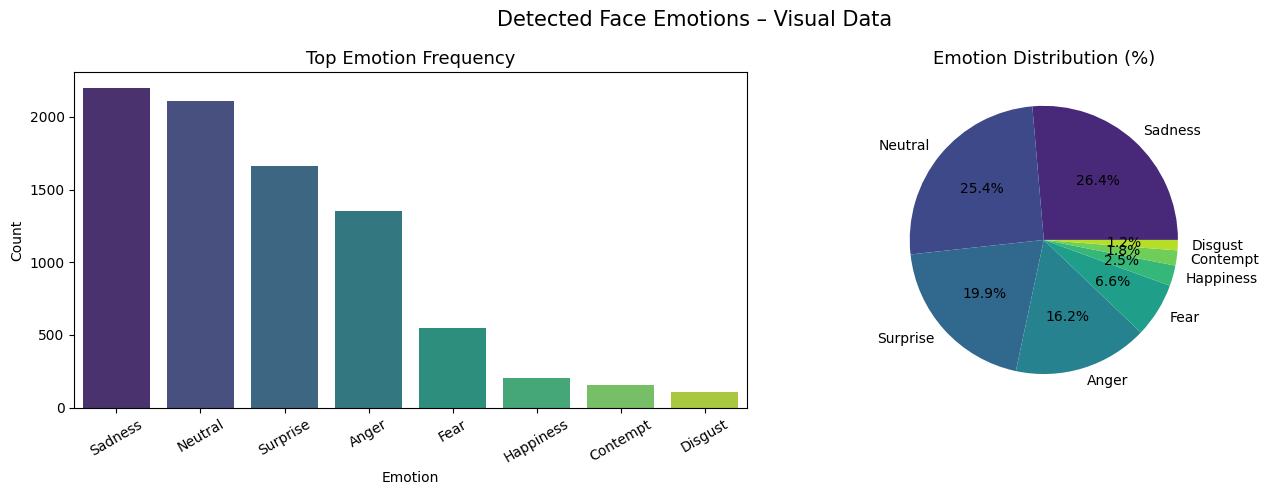

/tmp/ipykernel_448161/1205359068.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_probs.index, y=avg_probs.values, palette='magma')


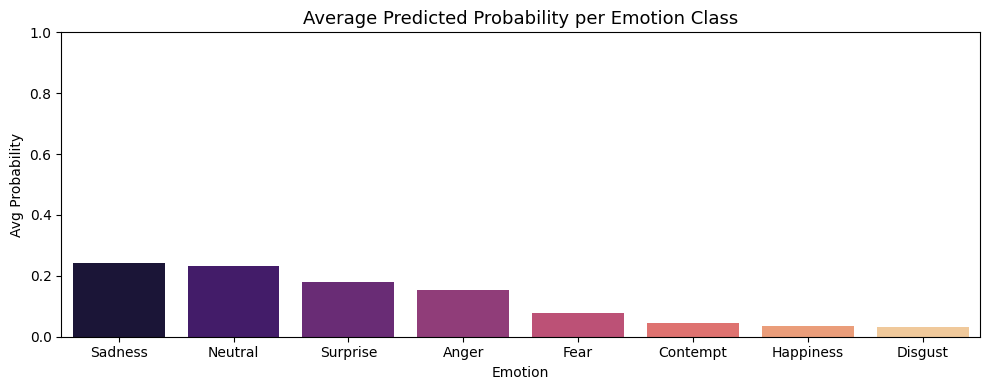

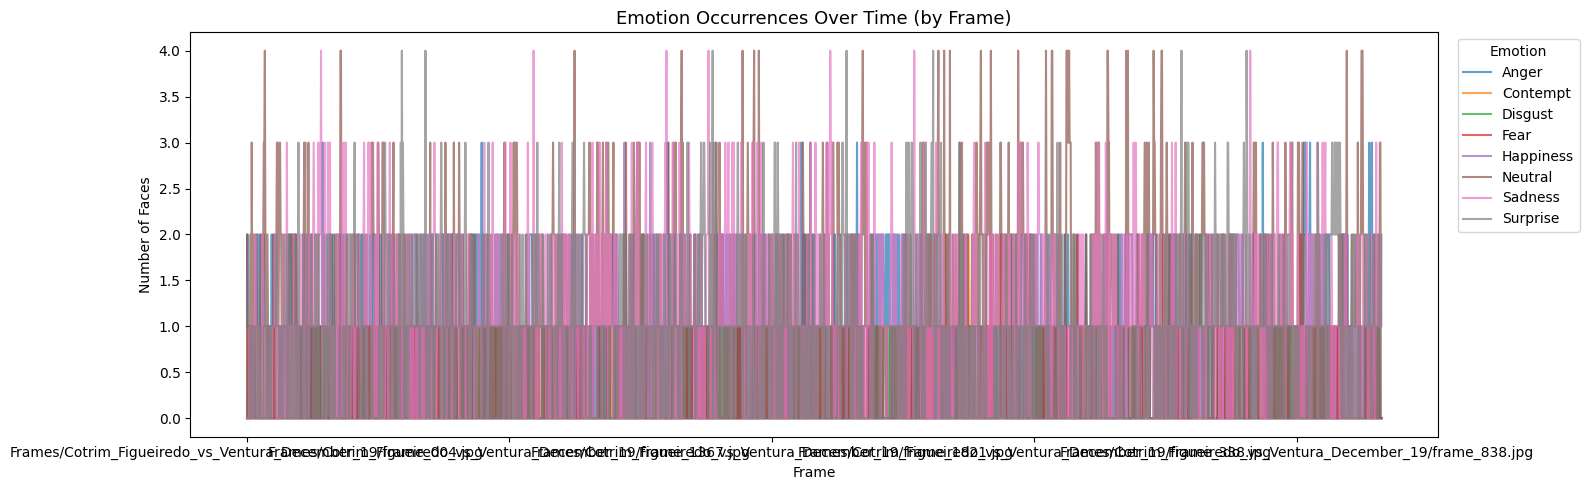

In [ ]:

if df_visual is None:
    print("Visual data not available — skipping emotion analysis.")
elif 'Fer' not in df_visual.columns:
    print("No 'fer' column found in visual data.")
else:
 
    faces_exploded = df_visual['Fer'].dropna().explode()
    faces_exploded = faces_exploded.dropna()


    top_emotions = faces_exploded.apply(lambda x: x['top_emotion'] if isinstance(x, dict) else None).dropna()

    probs_df = faces_exploded.apply(
        lambda x: x['probabilities'] if isinstance(x, dict) else None
    ).dropna().apply(pd.Series)

    emotion_counts = top_emotions.value_counts()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.barplot(x=emotion_counts.index, y=emotion_counts.values, ax=axes[0], palette='viridis')
    axes[0].set_title('Top Emotion Frequency', fontsize=13)
    axes[0].set_xlabel('Emotion')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=30)

    axes[1].pie(emotion_counts.values, labels=emotion_counts.index, autopct='%1.1f%%',
                colors=sns.color_palette('viridis', len(emotion_counts)))
    axes[1].set_title('Emotion Distribution (%)', fontsize=13)

    plt.suptitle('Detected Face Emotions – Visual Data', fontsize=15)
    plt.tight_layout()
    plt.show()

    avg_probs = probs_df.mean().sort_values(ascending=False)

    plt.figure(figsize=(10, 4))
    sns.barplot(x=avg_probs.index, y=avg_probs.values, palette='magma')
    plt.title('Average Predicted Probability per Emotion Class', fontsize=13)
    plt.ylabel('Avg Probability')
    plt.xlabel('Emotion')
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()


    df_visual_clean = df_visual[['Frame', 'Fer']].dropna()
    df_visual_clean = df_visual_clean.explode('Fer').dropna(subset=['Fer'])
    df_visual_clean['top_emotion'] = df_visual_clean['Fer'].apply(
        lambda x: x['top_emotion'] if isinstance(x, dict) else None
    )
    df_visual_clean = df_visual_clean.dropna(subset=['top_emotion'])

    emotion_over_time = df_visual_clean.groupby(['Frame', 'top_emotion']).size().unstack(fill_value=0)

    plt.figure(figsize=(16, 5))
    emotion_over_time.plot(ax=plt.gca(), alpha=0.7)
    plt.title('Emotion Occurrences Over Time (by Frame)', fontsize=13)
    plt.xlabel('Frame')
    plt.ylabel('Number of Faces')
    plt.legend(title='Emotion', bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

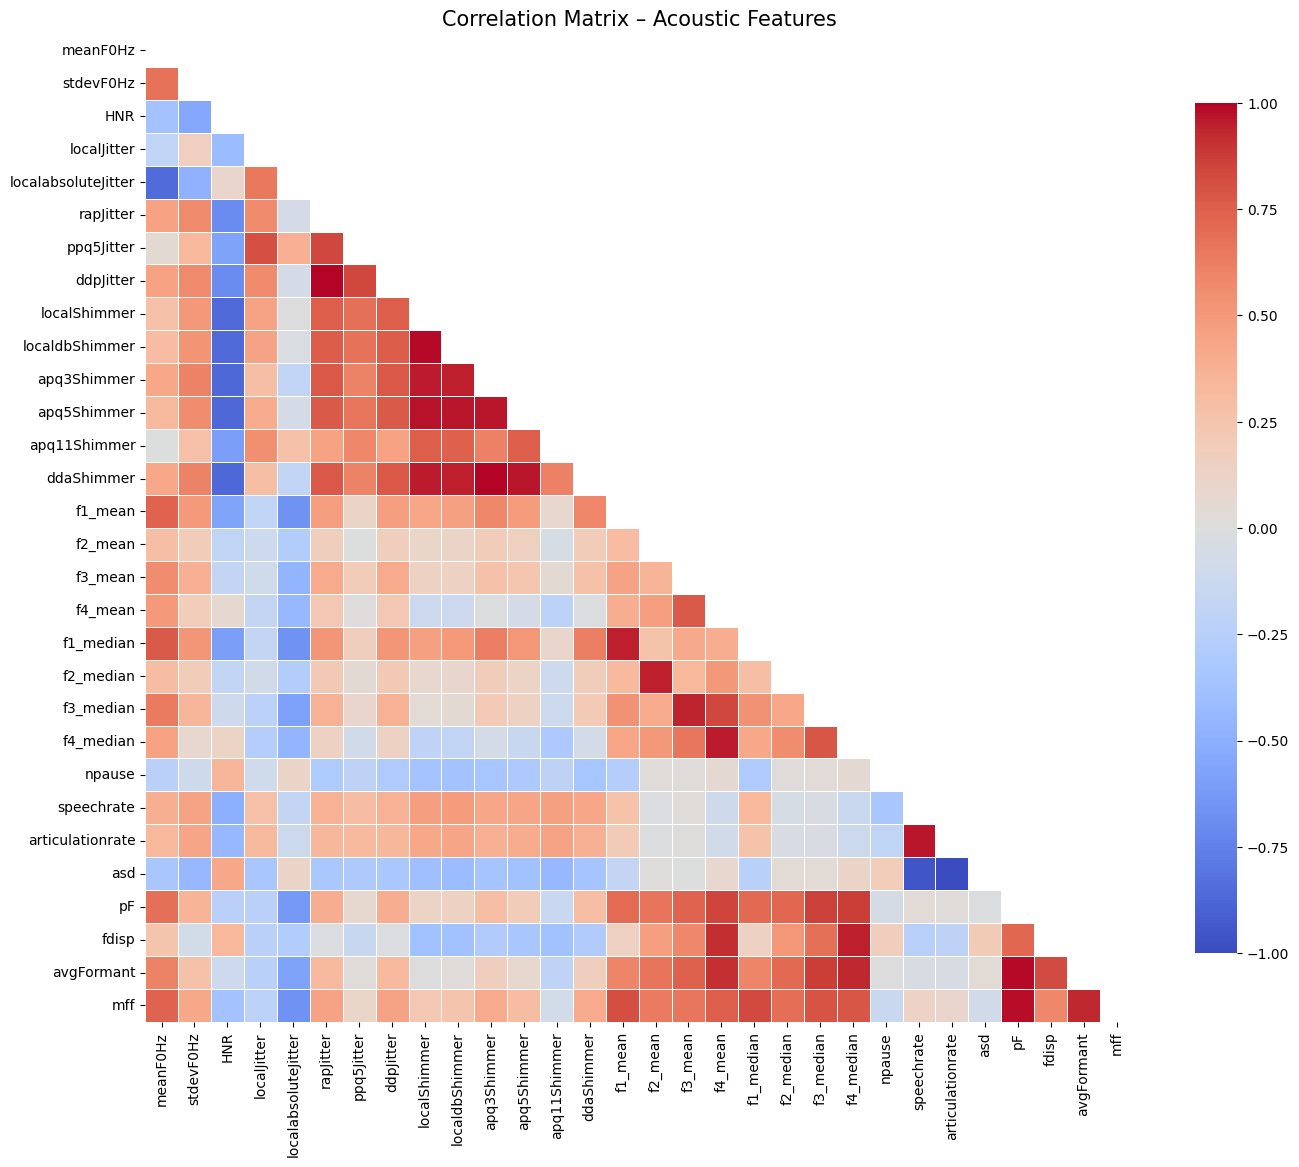

In [ ]:
if df_audio is None:
    print("Audio data not available — skipping correlation heatmap.")
else:
    available_feats = [f for f in acoustic_features if f in df_audio.columns]
    corr_matrix = df_audio[available_feats].dropna().corr()

    plt.figure(figsize=(14, 12))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(
        corr_matrix, mask=mask,
        cmap='coolwarm', center=0, vmin=-1, vmax=1,
        annot=False, linewidths=0.4, square=True,
        cbar_kws={"shrink": 0.8}
    )
    plt.title('Correlation Matrix – Acoustic Features', fontsize=15)
    plt.tight_layout()
    plt.show()

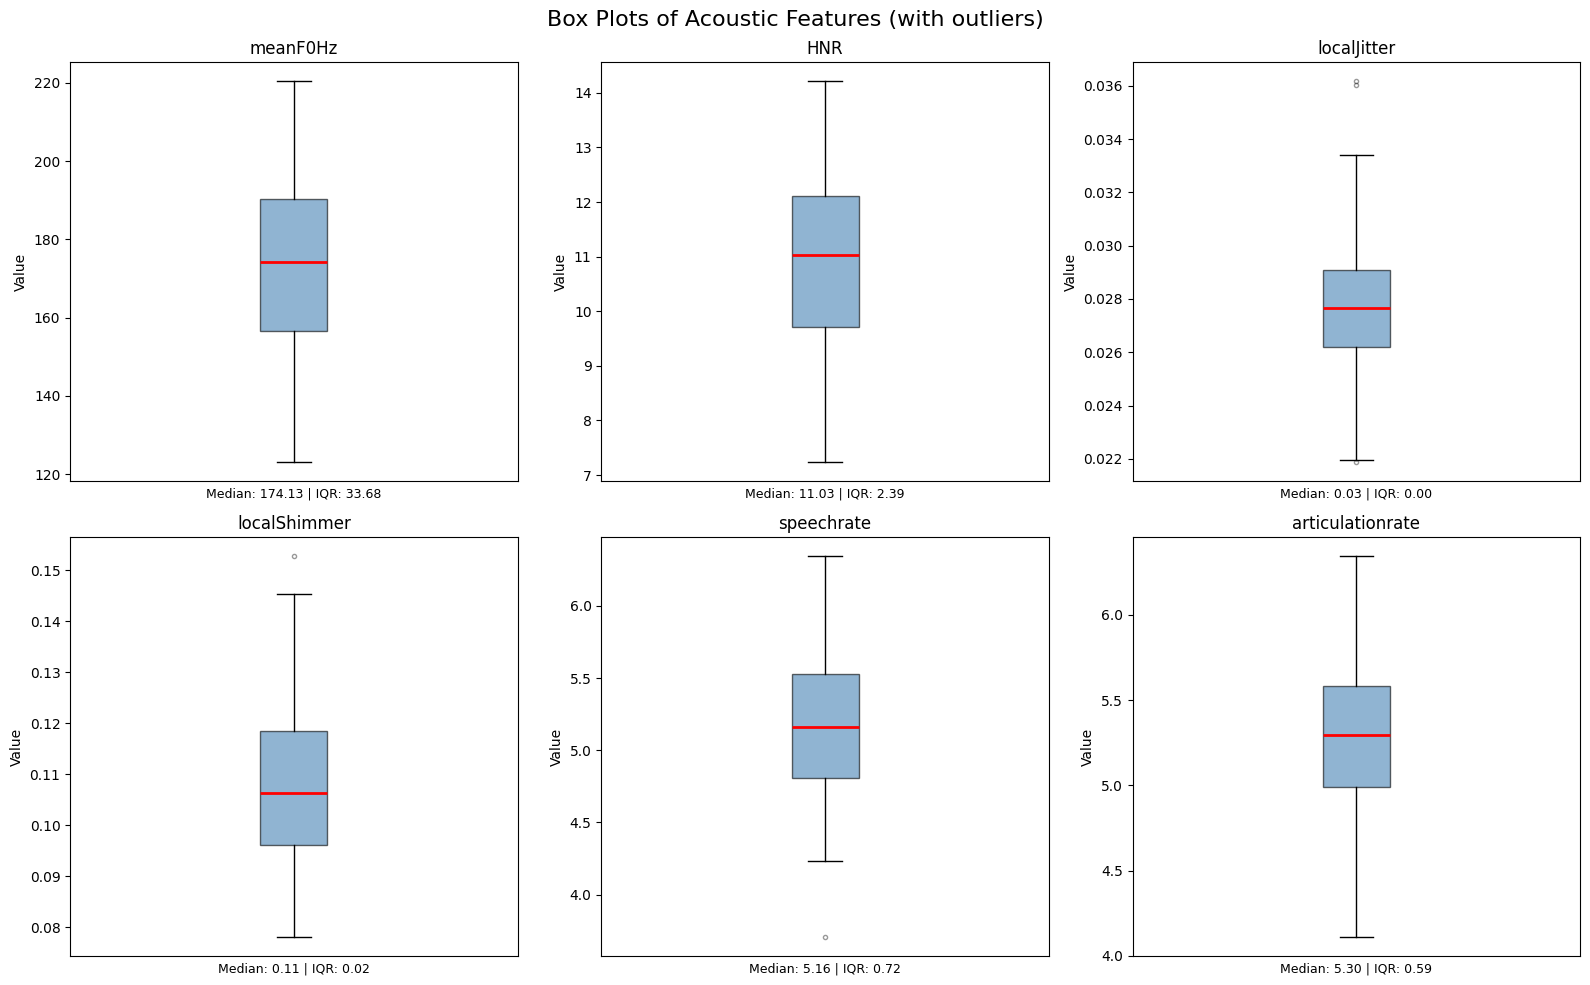

In [ ]:

features_to_plot = ['meanF0Hz', 'HNR', 'localJitter', 'localShimmer', 'speechrate', 'articulationrate']

if df_audio is None:
    print("Audio data not available — skipping box plots.")
else:
    available_feats = [f for f in features_to_plot if f in df_audio.columns]

    if not available_feats:
        print("None of the target features found in audio dataframe.")
    else:
        n = len(available_feats)
        fig, axes = plt.subplots(2, -(-n // 2), figsize=(16, 10))
        axes = axes.flatten()

        for i, feat in enumerate(available_feats):
            data = df_audio[feat].dropna()
            axes[i].boxplot(data, vert=True, patch_artist=True,
                            boxprops=dict(facecolor='steelblue', alpha=0.6),
                            medianprops=dict(color='red', linewidth=2),
                            flierprops=dict(marker='o', markersize=3, alpha=0.4))
            axes[i].set_title(feat, fontsize=12)
            axes[i].set_ylabel('Value')
            axes[i].set_xticks([])
            q1, median, q3 = data.quantile([0.25, 0.5, 0.75])
            axes[i].set_xlabel(f'Median: {median:.2f} | IQR: {q3-q1:.2f}', fontsize=9)

        for j in range(i + 1, len(axes)):
            axes[j].set_visible(False)

        plt.suptitle('Box Plots of Acoustic Features (with outliers)', fontsize=16)
        plt.tight_layout()
        plt.show()

////////////////////////////////////////////////////////////////////////////////////////

Sorting the visual pkl by frame + cleaning the visual pkls all of them and saving

In [ ]:
def compute_intersection_area(box1, box2):
    x_left   = max(box1[0], box2[0])
    y_top    = max(box1[1], box2[1])
    x_right  = min(box1[2], box2[2])
    y_bottom = min(box1[3], box2[3])
    if x_right < x_left or y_bottom < y_top:
        return 0.0
    return (x_right - x_left) * (y_bottom - y_top)

def calcular_area(box):
    return (box[2] - box[0]) * (box[3] - box[1])

def apply_containment_filter(detections, containment_threshold=0.90):
    if not detections:
        return []
    detections_sorted = sorted(
        detections,
        key=lambda k: calcular_area(k['bbox']) if 'bbox' in k else 0,
        reverse=True
    )
    kept_boxes = []
    for current_det in detections_sorted:
        if 'bbox' not in current_det:
            continue
        current_bbox  = current_det['bbox']
        current_area  = calcular_area(current_bbox)
        if current_area == 0:
            continue
        is_contained = False
        for kept_det in kept_boxes:
            inter_area     = compute_intersection_area(current_bbox, kept_det['bbox'])
            coverage_ratio = inter_area / current_area
            if coverage_ratio >= containment_threshold:
                is_contained = True
                break
        if not is_contained:
            kept_boxes.append(current_det)
    return kept_boxes

def count_persons(poses_list):
    if not isinstance(poses_list, list) or len(poses_list) == 0:
        return 0
    return sum(1 for p in poses_list if 'bbox' in p)

def extrair_dados_validos(lista_deteccoes, img_width=1280, img_height=720, area_min=10000):

    if not isinstance(lista_deteccoes, list) or len(lista_deteccoes) == 0:
        return []

    Y_CUTOFF    = img_height * 0.55
    LEFT_ZONE   = img_width  * 0.25
    RIGHT_ZONE  = img_width  * 0.75

    pre_clean = []
    for detec in lista_deteccoes:
        if 'bbox' not in detec:
            continue
        x1, y1, x2, y2 = detec['bbox']
        center_x = (x1 + x2) / 2
        center_y = (y1 + y2) / 2
        area     = calcular_area(detec['bbox'])

        in_bottom_left  = (center_x < LEFT_ZONE)  and (center_y > Y_CUTOFF)
        in_bottom_right = (center_x > RIGHT_ZONE) and (center_y > Y_CUTOFF)

        if not (in_bottom_left or in_bottom_right) and (area > area_min):
            pre_clean.append(detec)

    return apply_containment_filter(pre_clean, containment_threshold=0.60)


def extrair_fer_validos(fer_list, valid_poses,
                        img_width=1280, img_height=720,
                        area_min=900,
                        min_confidence=0.50,
                        pose_coverage_threshold=0.60):

    if not isinstance(fer_list, list) or len(fer_list) == 0:
        return []

    Y_CUTOFF   = img_height * 0.55
    LEFT_ZONE  = img_width  * 0.25
    RIGHT_ZONE = img_width  * 0.75


    pre_clean = []
    for face in fer_list:
        if 'bbox' not in face:
            continue
        x1, y1, x2, y2 = face['bbox']
        center_x = (x1 + x2) / 2
        center_y = (y1 + y2) / 2
        area     = calcular_area(face['bbox'])

        in_bottom_left  = (center_x < LEFT_ZONE)  and (center_y > Y_CUTOFF)
        in_bottom_right = (center_x > RIGHT_ZONE) and (center_y > Y_CUTOFF)

        if not (in_bottom_left or in_bottom_right) and (area > area_min):
            pre_clean.append(face)


    after_containment = apply_containment_filter(pre_clean, containment_threshold=0.80)


    after_confidence = []
    for face in after_containment:
        top_emotion = face.get('top_emotion')
        probs       = face.get('probabilities', {})
        confidence  = probs.get(top_emotion, 0.0) if top_emotion else 0.0

        if confidence >= min_confidence:
            after_confidence.append(face)

    if not isinstance(valid_poses, list) or len(valid_poses) == 0:
        return []  # no valid poses at all → no valid faces

    final = []
    for face in after_confidence:
        face_bbox = face['bbox']
        face_area = calcular_area(face_bbox)
        if face_area == 0:
            continue

        has_pose_backing = False
        for pose in valid_poses:
            if 'bbox' not in pose:
                continue
            inter         = compute_intersection_area(face_bbox, pose['bbox'])
            face_coverage = inter / face_area  # % of face covered by this pose box
            if face_coverage >= pose_coverage_threshold:
                has_pose_backing = True
                break

        if has_pose_backing:
            final.append(face)

    return final

df_visual['total_person_count'] = df_visual['Poses'].apply(count_persons)

df_visual['valid_poses'] = df_visual['Poses'].apply(
    lambda x: extrair_dados_validos(x, area_min=10000)
)

df_visual['valid_fer'] = df_visual.apply(
    lambda row: extrair_fer_validos(
        row['Fer'],
        row['valid_poses'],
        area_min=200,
        min_confidence=0.05,
        pose_coverage_threshold=0.500
    ),
    axis=1
)

df_visual['valid_person_count'] = df_visual['valid_poses'].apply(lambda x: len(x) if isinstance(x, list) else 0)
df_visual['valid_poses_count']  = df_visual['valid_poses'].apply(lambda x: len(x) if isinstance(x, list) else 0)
df_visual['valid_fer_count']    = df_visual['valid_fer'].apply(lambda x: len(x) if isinstance(x, list) else 0)


mismatches = df_visual[df_visual['valid_poses_count'] != df_visual['valid_fer_count']]

if mismatches.empty:
    print("✓ All frames have matching pose and FER counts.")
else:
    print(f"⚠ WARNING: {len(mismatches)} frame(s) have mismatched counts:\n")
    for idx, row in mismatches.iterrows():
        print(f"  Frame {idx:>5} — valid_poses: {row['valid_poses_count']}  |  valid_fer: {row['valid_fer_count']}  |  diff: {abs(row['valid_poses_count'] - row['valid_fer_count'])}")
    
    print(f"\nSummary:")
    print(f"  Total frames:       {len(df_visual)}")
    print(f"  Matching frames:    {len(df_visual) - len(mismatches)}  ({(1 - len(mismatches)/len(df_visual))*100:.1f}%)")
    print(f"  Mismatched frames:  {len(mismatches)}  ({len(mismatches)/len(df_visual)*100:.1f}%)")
    print(f"  Avg pose count:     {df_visual['valid_poses_count'].mean():.2f}")
    print(f"  Avg FER count:      {df_visual['valid_fer_count'].mean():.2f}")


def clean_visual_df(df_visual,
                    area_min_poses=10000,
                    area_min_fer=200,
                    min_confidence=0.05,
                    pose_coverage_threshold=0.50):
    """
    Applies all cleaning filters to a visual dataframe and returns it
    with the new cleaned columns added.
    """
    df = df_visual.copy()

    df['frame_idx'] = df['Frame'].str.extract(r'frame_(\d+)').astype(int)
    df = df.sort_values('frame_idx').set_index('frame_idx')
    print(f"  Sorted — timeline: frame {df.index.min()} → {df.index.max()}")

    df['total_person_count'] = df['Poses'].apply(count_persons)

    df['valid_poses'] = df['Poses'].apply(
        lambda x: extrair_dados_validos(x, area_min=area_min_poses)
    )

    df['valid_fer'] = df.apply(
        lambda row: extrair_fer_validos(
            row['Fer'],
            row['valid_poses'],
            area_min=area_min_fer,
            min_confidence=min_confidence,
            pose_coverage_threshold=pose_coverage_threshold
        ),
        axis=1
    )

    df['valid_person_count'] = df['valid_poses'].apply(lambda x: len(x) if isinstance(x, list) else 0)
    df['valid_poses_count']  = df['valid_poses'].apply(lambda x: len(x) if isinstance(x, list) else 0)
    df['valid_fer_count']    = df['valid_fer'].apply(lambda x: len(x) if isinstance(x, list) else 0)

    return df


def sanity_check(df_visual, debate_name):
    """Prints a mismatch report for poses vs FER counts."""
    mismatches = df_visual[df_visual['valid_poses_count'] != df_visual['valid_fer_count']]

    if mismatches.empty:
        print(f"  ✓ [{debate_name}] All frames have matching pose and FER counts.")
    else:
        print(f"  ⚠ [{debate_name}] {len(mismatches)} mismatched frame(s):")
        for idx, row in mismatches.iterrows():
            print(f"    Frame {idx:>5} — poses: {row['valid_poses_count']}  |  fer: {row['valid_fer_count']}  |  diff: {abs(row['valid_poses_count'] - row['valid_fer_count'])}")
        print(f"    Matching: {len(df_visual) - len(mismatches)}/{len(df_visual)} ({(1 - len(mismatches)/len(df_visual))*100:.1f}%)")


# for all files
features_dir    = "Project_Features/"
output_dir      = "cleaned_features/"
os.makedirs(output_dir, exist_ok=True)

visual_files = sorted([
    f for f in os.listdir(features_dir)
    if f.endswith('_visual.pkl')
])

print(f"Found {len(visual_files)} visual file(s) to process.\n")

for file_name in visual_files:
    debate_name = file_name.replace('_visual.pkl', '')
    input_path  = os.path.join(features_dir, file_name)
    output_path = os.path.join(output_dir, file_name)

    print(f"[{debate_name}]")

    try:
        df_visual = pd.read_pickle(input_path)
        print(f"  Loaded — {df_visual.shape[0]} frames")

        df_cleaned = clean_visual_df(df_visual)

        sanity_check(df_cleaned, debate_name)

        df_cleaned.to_pickle(output_path)
        print(f"  Saved → {output_path}\n")

    except Exception as e:
        print(f"  ✗ Error processing {file_name}: {e}\n")

print("Done.")

⚠ WARNING: 13 frame(s) have mismatched counts:

  Frame   552 — valid_poses: 4  |  valid_fer: 3  |  diff: 1
  Frame   643 — valid_poses: 4  |  valid_fer: 3  |  diff: 1
  Frame   692 — valid_poses: 2  |  valid_fer: 3  |  diff: 1
  Frame   705 — valid_poses: 2  |  valid_fer: 3  |  diff: 1
  Frame  1336 — valid_poses: 4  |  valid_fer: 3  |  diff: 1
  Frame  1426 — valid_poses: 2  |  valid_fer: 3  |  diff: 1
  Frame  1497 — valid_poses: 2  |  valid_fer: 1  |  diff: 1
  Frame  1586 — valid_poses: 4  |  valid_fer: 3  |  diff: 1
  Frame  1635 — valid_poses: 4  |  valid_fer: 3  |  diff: 1
  Frame  1647 — valid_poses: 4  |  valid_fer: 3  |  diff: 1
  Frame  1650 — valid_poses: 4  |  valid_fer: 3  |  diff: 1
  Frame  1812 — valid_poses: 3  |  valid_fer: 2  |  diff: 1
  Frame  1953 — valid_poses: 2  |  valid_fer: 3  |  diff: 1

Summary:
  Total frames:       2070
  Matching frames:    2057  (99.4%)
  Mismatched frames:  13  (0.6%)
  Avg pose count:     1.81
  Avg FER count:      1.80
Found 28 vis

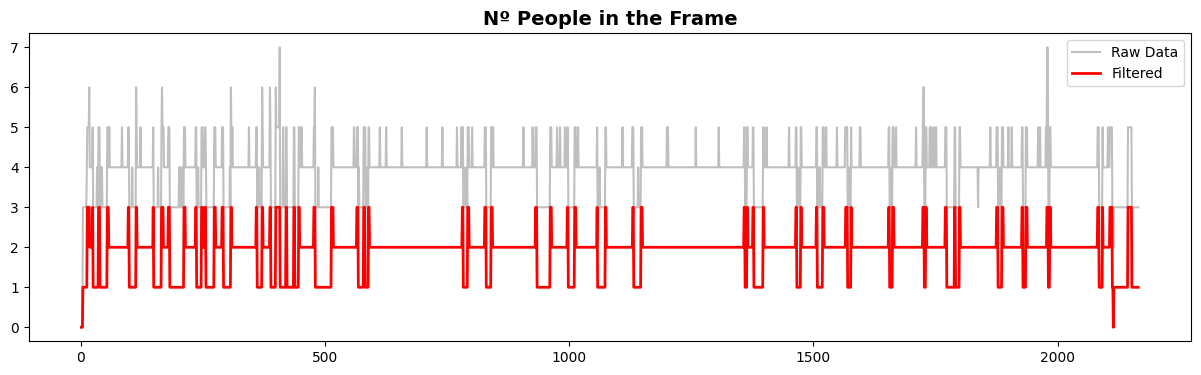

In [10]:
df_visual = pd.read_pickle("cleaned_features/Cotrim_Figueiredo_vs_Ventura_December_19_visual.pkl")
plt.figure(figsize=(15, 4))
plt.plot(df_visual.index, df_visual['total_person_count'], label='Raw Data', color='grey', alpha=0.5)
plt.plot(df_visual.index, df_visual['valid_person_count'], label='Filtered', color='red', linewidth=2)
plt.title("Nº People in the Frame", fontsize=14, fontweight='bold')
plt.legend()
plt.show()

# Debug Visual Frame

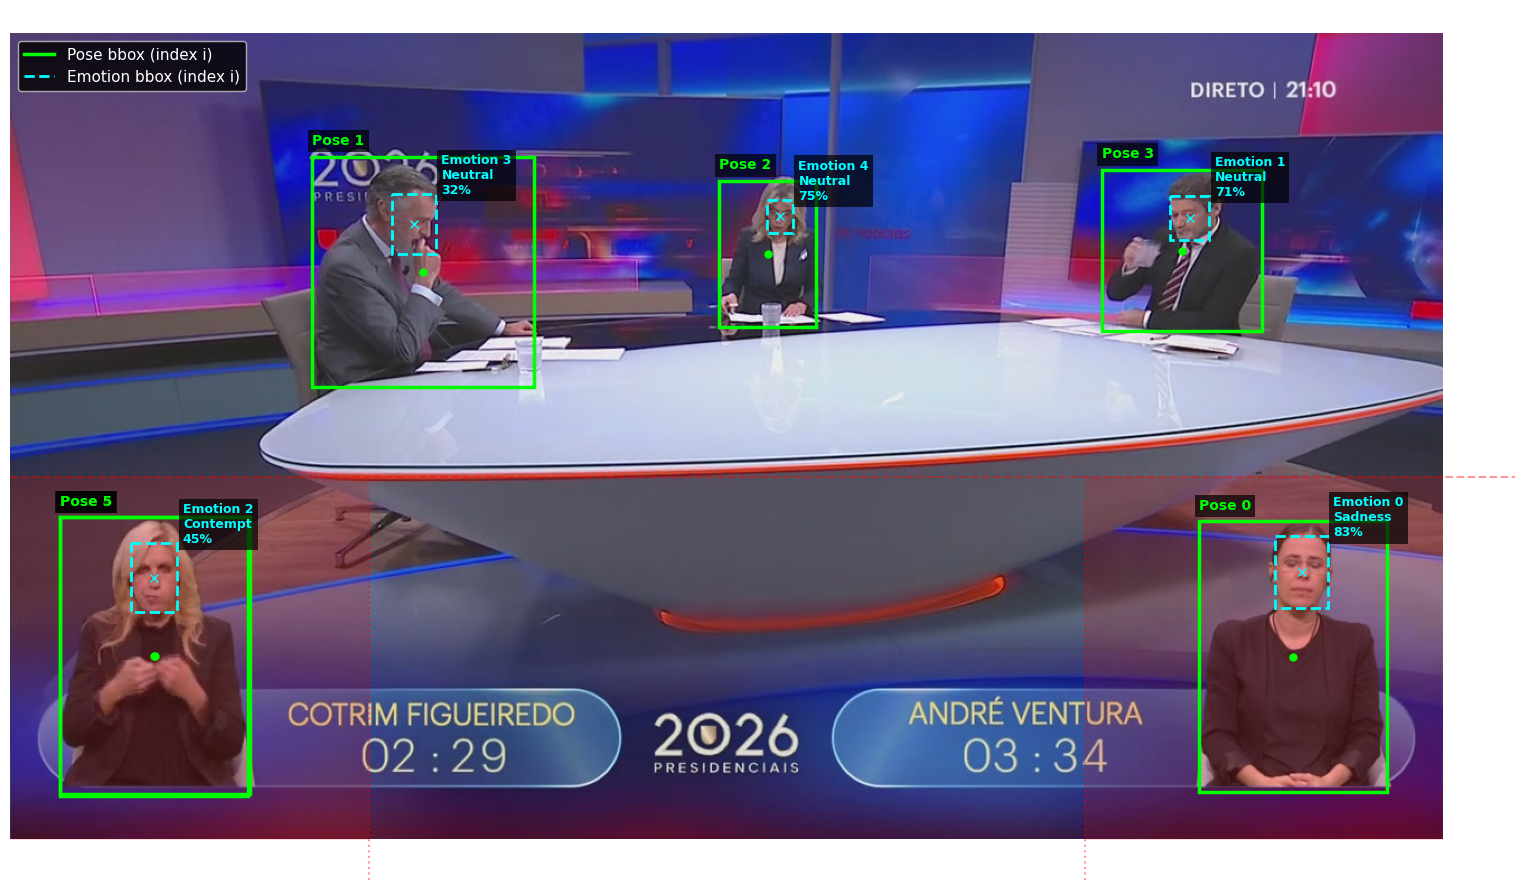


i     Pose bbox                           Emotion bbox                        Emotion
----------------------------------------------------------------------------------------------------
0     [1062.0319   435.47726 1230.0103   677.8298 ] [np.int64(1130), np.int64(449), np.int64(1177), np.int64(513)] Sadness
1     [269.51785 109.571   467.85492 315.46585] [np.int64(1036), np.int64(145), np.int64(1071), np.int64(184)] Neutral
2     [633.2589  131.04536 719.6316  262.07968] [np.int64(108), np.int64(455), np.int64(149), np.int64(517)] Contempt
3     [ 974.9397   121.25046 1117.9889   265.84677] [np.int64(341), np.int64(143), np.int64(380), np.int64(197)] Neutral
4     [ 43.812996 431.62357  213.78769  679.3004  ] [np.int64(676), np.int64(148), np.int64(699), np.int64(178)] Neutral
5     [ 44.364616 431.72168  212.21176  680.58575 ] MISSING                             MISSING


In [ ]:
frame_alvo = 479
pasta_imagens = 'frames_files/Cotrim_Figueiredo_vs_Ventura_December_19/'
caminho_imagem = os.path.join(pasta_imagens, f'frame_{frame_alvo:03d}.jpg')


poses_do_frame = df_visual.loc[frame_alvo, 'Poses']
fer_do_frame   = df_visual.loc[frame_alvo, 'Fer']  # Use the cleaned FER detections

IMG_WIDTH  = 1280
IMG_HEIGHT = 720
Y_CUTOFF    = IMG_HEIGHT * 0.55
LEFT_ZONE   = IMG_WIDTH  * 0.25
RIGHT_ZONE  = IMG_WIDTH  * 0.75


fig, ax = plt.subplots(1, figsize=(16, 9))
ax.set_facecolor('#222222')

try:
    img = plt.imread(caminho_imagem)
    ax.imshow(img)
except FileNotFoundError:
    print(f"Imagem não encontrada: {caminho_imagem}")
    ax.set_xlim(0, IMG_WIDTH)
    ax.set_ylim(IMG_HEIGHT, 0)

#apply zones
ax.add_patch(patches.Rectangle((0, Y_CUTOFF), LEFT_ZONE, IMG_HEIGHT - Y_CUTOFF,
                                linewidth=0, facecolor='red', alpha=0.15))
ax.add_patch(patches.Rectangle((RIGHT_ZONE, Y_CUTOFF), IMG_WIDTH - RIGHT_ZONE, IMG_HEIGHT - Y_CUTOFF,
                                linewidth=0, facecolor='red', alpha=0.15))
ax.axhline(Y_CUTOFF, color='red', linestyle='--', alpha=0.4, label='Y Cutoff')
ax.axvline(LEFT_ZONE,  ymin=0, ymax=1 - (Y_CUTOFF / IMG_HEIGHT), color='red', linestyle=':', alpha=0.4)
ax.axvline(RIGHT_ZONE, ymin=0, ymax=1 - (Y_CUTOFF / IMG_HEIGHT), color='red', linestyle=':', alpha=0.4)


if isinstance(poses_do_frame, list):
    for i, person in enumerate(poses_do_frame):
        if isinstance(person, dict) and 'bbox' in person:
            x1, y1, x2, y2 = person['bbox']
            w, h = x2 - x1, y2 - y1
            center_x, center_y = x1 + w / 2, y1 + h / 2

            ax.add_patch(patches.Rectangle((x1, y1), w, h,
                                           linewidth=2.5, edgecolor='lime', facecolor='none',
                                           linestyle='-'))
            ax.plot(center_x, center_y, marker='o', color='lime', markersize=5)
            ax.text(x1, y1 - 10, f"Pose {i}", color='lime', fontsize=10, fontweight='bold',
                    bbox=dict(facecolor='black', alpha=0.7, edgecolor='none', pad=3))
else:
    print("poses_do_frame is not a list — check column structure.")


if isinstance(fer_do_frame, list):
    for i, face in enumerate(fer_do_frame):
        if isinstance(face, dict) and 'bbox' in face:
            x1, y1, x2, y2 = face['bbox']
            w, h = x2 - x1, y2 - y1
            center_x, center_y = x1 + w / 2, y1 + h / 2
            emotion = face.get('top_emotion', '?')
            conf    = face['probabilities'].get(emotion, 0) if 'probabilities' in face else 0

            ax.add_patch(patches.Rectangle((x1, y1), w, h,
                                           linewidth=2, edgecolor='cyan', facecolor='none',
                                           linestyle='--'))
            ax.plot(center_x, center_y, marker='x', color='cyan', markersize=6)
            ax.text(x2 + 5, y1, f"Emotion {i}\n{emotion}\n{conf:.0%}",
                    color='cyan', fontsize=9, fontweight='bold',
                    bbox=dict(facecolor='black', alpha=0.7, edgecolor='none', pad=3))
else:
    print("fer_do_frame is not a list — check column structure.")

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='lime', linewidth=2.5, label='Pose bbox (index i)'),
    Line2D([0], [0], color='cyan', linewidth=2, linestyle='--', label='Emotion bbox (index i)'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=11,
          facecolor='black', labelcolor='white')

plt.title(f"Pose + FER Debugger: Frame {frame_alvo}  "
          f"({len(poses_do_frame) if isinstance(poses_do_frame, list) else 0} poses, "
          f"{len(fer_do_frame) if isinstance(fer_do_frame, list) else 0} faces)",
          fontsize=14, fontweight='bold', color='white')
plt.axis('off')
plt.tight_layout()
plt.show()


print(f"\n{'i':<5} {'Pose bbox':<35} {'Emotion bbox':<35} {'Emotion'}")
print("-" * 100)
n = max(
    len(poses_do_frame) if isinstance(poses_do_frame, list) else 0,
    len(fer_do_frame)   if isinstance(fer_do_frame,   list) else 0
)
for i in range(n):
    pose_bbox = poses_do_frame[i]['bbox'] if isinstance(poses_do_frame, list) and i < len(poses_do_frame) else "MISSING"
    fer_entry = fer_do_frame[i]           if isinstance(fer_do_frame,   list) and i < len(fer_do_frame)   else None
    fer_bbox  = fer_entry['bbox']         if isinstance(fer_entry, dict) else "MISSING"
    emotion   = fer_entry.get('top_emotion', '?') if isinstance(fer_entry, dict) else "MISSING"
    print(f"{i:<5} {str(pose_bbox):<35} {str(fer_bbox):<35} {emotion}")

# emotion vs pitch boxplot 

/tmp/ipykernel_9171/211778874.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


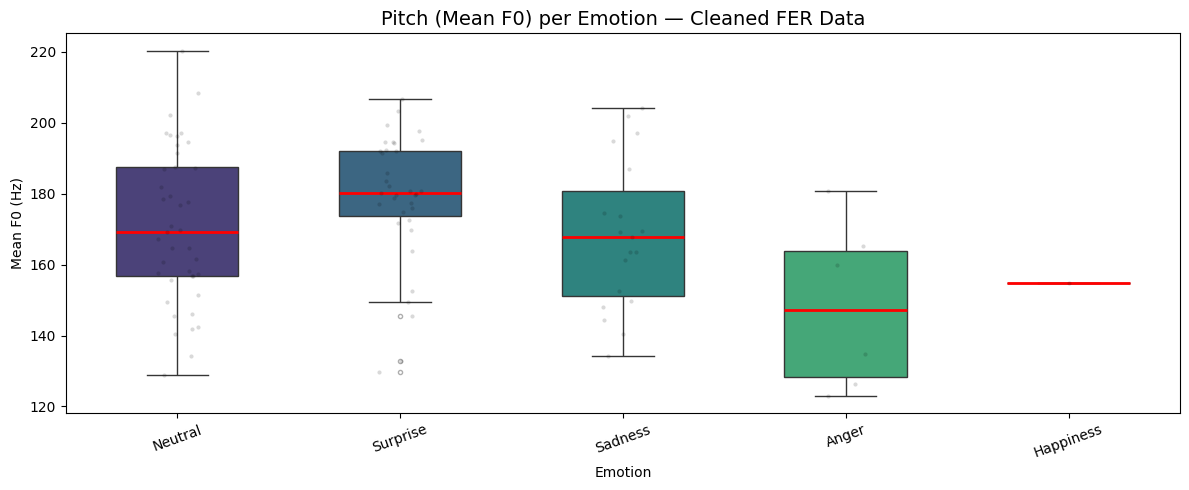

In [ ]:

emotion_order = df_merged['emotion'].value_counts().index.tolist()
palette       = dict(zip(emotion_order, sns.color_palette('viridis', len(emotion_order))))

plt.figure(figsize=(12, 5))
sns.boxplot(
    data=df_merged,
    x='emotion', y='meanF0Hz',
    order=emotion_order,
    palette=palette,
    width=0.55,
    flierprops=dict(marker='o', markersize=3, alpha=0.4),
    medianprops=dict(color='red', linewidth=2),
)
sns.stripplot(
    data=df_merged,
    x='emotion', y='meanF0Hz',
    order=emotion_order,
    color='black', alpha=0.15, size=3, jitter=True
)
plt.title('Pitch (Mean F0) per Emotion — Cleaned FER Data', fontsize=14)
plt.xlabel('Emotion')
plt.ylabel('Mean F0 (Hz)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# emotion vs speaking rate boxplot

/tmp/ipykernel_9171/1548858595.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_9171/1548858595.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


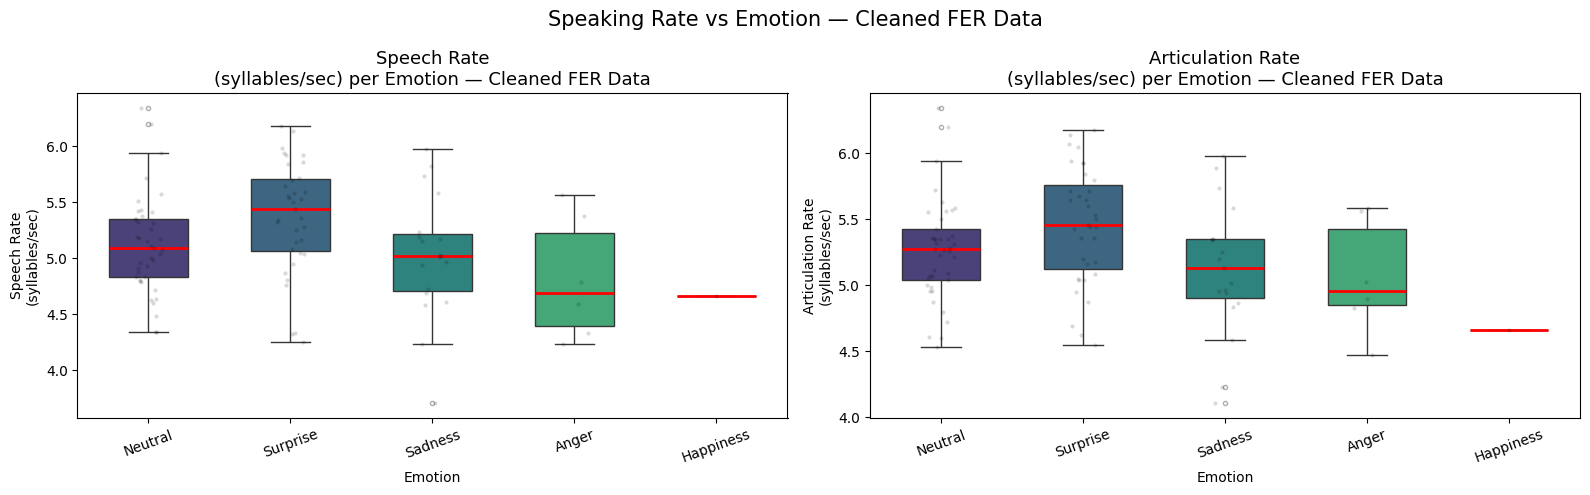

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, col, label in zip(
    axes,
    ['speechrate',       'articulationrate'],
    ['Speech Rate\n(syllables/sec)', 'Articulation Rate\n(syllables/sec)']
):
    sns.boxplot(
        data=df_merged,
        x='emotion', y=col,
        order=emotion_order,
        palette=palette,
        width=0.55,
        flierprops=dict(marker='o', markersize=3, alpha=0.4),
        medianprops=dict(color='red', linewidth=2),
        ax=ax
    )
    sns.stripplot(
        data=df_merged,
        x='emotion', y=col,
        order=emotion_order,
        color='black', alpha=0.15, size=3, jitter=True,
        ax=ax
    )
    ax.set_title(f'{label} per Emotion — Cleaned FER Data', fontsize=13)
    ax.set_xlabel('Emotion')
    ax.set_ylabel(label)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Speaking Rate vs Emotion — Cleaned FER Data', fontsize=15)
plt.tight_layout()
plt.show()

# Emotion histogram 

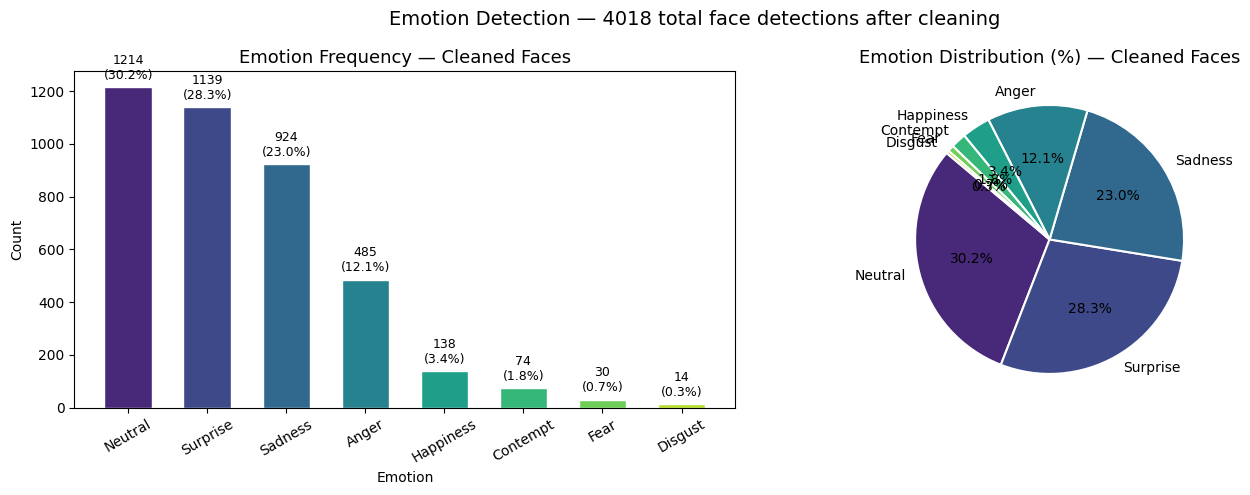


Total detections: 4018
           count   pct
Neutral     1214  30.2
Surprise    1139  28.3
Sadness      924  23.0
Anger        485  12.1
Happiness    138   3.4
Contempt      74   1.8
Fear          30   0.7
Disgust       14   0.3


In [ ]:
all_emotions = []
for fer_list in df_visual['valid_fer'].dropna():
    if isinstance(fer_list, list):
        for face in fer_list:
            if isinstance(face, dict) and 'top_emotion' in face:
                all_emotions.append(face['top_emotion'])

emotion_counts = pd.Series(all_emotions).value_counts()
total          = len(all_emotions)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


bars = axes[0].bar(emotion_counts.index, emotion_counts.values,
                   color=sns.color_palette('viridis', len(emotion_counts)),
                   edgecolor='white', width=0.6)
axes[0].set_title('Emotion Frequency — Cleaned Faces', fontsize=13)
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
# add count labels on top of each bar
for bar, count in zip(bars, emotion_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + total * 0.005,
                 f'{count}\n({count/total*100:.1f}%)',
                 ha='center', va='bottom', fontsize=9)

#  Pie chart 
axes[1].pie(
    emotion_counts.values,
    labels=emotion_counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('viridis', len(emotion_counts)),
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
axes[1].set_title('Emotion Distribution (%) — Cleaned Faces', fontsize=13)

plt.suptitle(f'Emotion Detection — {total} total face detections after cleaning', fontsize=14)
plt.tight_layout()
plt.show()

# quick summary printout
print(f"\nTotal detections: {total}")
print(emotion_counts.rename('count').to_frame()
      .assign(pct=lambda d: (d['count'] / total * 100).round(1)))